# Diferential Expression (DE) v2

In [2]:
# load packages and user-defined functions
options(warn=-1)
suppressPackageStartupMessages( library( DESeq2 ) )
suppressPackageStartupMessages( library( BiocParallel ) )
library(tidyverse)
library(data.table)
library("AnnotationDbi")
library("org.Hs.eg.db")
library(pathview)
library(gage)
library(gageData)
data(kegg.sets.hs)
data(sigmet.idx.hs)
library(scran)
library('glmGamPoi')
#library(parallel)
library(clusterProfiler)
library(EnhancedVolcano)
library("enrichplot")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()


In [3]:
suppressMessages(source("code/functions.R"))

In [4]:
reference_cells <- read.csv("output/reference_cell_strict.csv") %>% dplyr::select(experiment,cell)

In [5]:
reference_cells

experiment,cell
<chr>,<chr>
K1B,AAACCTGTCGGCTTGG
K1B,ACACCAAGTCCTGCTT
K1B,ACACTGAGTCCAGTAT
K1B,ACGAGCCCAGTGGGAT
K1B,ACGTCAAAGAGCCCAA
K1B,ACGTCAACATTGAGCT
K1B,ACTGAACCATCAGTCA
K1B,ACTGCTCAGCCACGTC
K1B,AGCAGCCAGTGACTCT


In [4]:
# # seurat object
# FL.integrated <- readRDS("output/K12345678_integrated.rds")

In [5]:
#barcodes of cells group 2
cells1 <- read.csv("output/df_summary_K12345678_v3.csv") %>% mutate(experiment=str_extract(subject, "^.{3}")) %>%
         mutate(cell_seurat=case_when(experiment == "K1B" ~ paste0(cell,"-1_1"),
                                                           experiment == "K2B" ~ paste0(cell,"-1_2"),
                                                           experiment == "K3B" ~ paste0(cell,"-1_3"),
                                                           experiment == "K4B" ~ paste0(cell,"-1_4"),
                                                                                             experiment == "K5B" ~ paste0(cell,"-1_5"),
                                                                                             experiment == "K6B" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7B" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8B" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>%
        rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

#barcodes of cells group 1
# cells2 <- df_seq %>% filter(cell %in% trully_negative$cell) %>% mutate(experiment=str_extract(subject, "^.{2}")) %>% mutate(cell_seurat=case_when(experiment == "K4" ~ paste0(cell,"-1_1"),
#                                                                                              experiment == "K5" ~ paste0(cell,"-1_2"),
#                                                                                              experiment == "K6" ~ paste0(cell,"-1_3"),
#                                                                                              experiment == "K7" ~ paste0(cell,"-1_4"),
#                                                                                              experiment == "K8" ~ paste0(cell,"-1_5"),
#                                                                                              TRUE ~ "NA"
#                                                                                                  )) %>% filter(!cell_seurat %in% cells1) %>%
#            pull(cell_seurat) %>% unique() %>% sample(2000)

cells2 <- reference_cells %>% mutate(cell_seurat=case_when(experiment == "K1B" ~ paste0(cell,"-1_1"),
                                                           experiment == "K2B" ~ paste0(cell,"-1_2"),
                                                           experiment == "K3B" ~ paste0(cell,"-1_3"),
                                                           experiment == "K4B" ~ paste0(cell,"-1_4"),
                                                                                             experiment == "K5B" ~ paste0(cell,"-1_5"),
                                                                                             experiment == "K6B" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7B" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8B" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [6]:
# cells1 %>% str()
# cells2 %>% str()

**The package DESeq2 provides methods to test for differential expression by use of negative binomial generalized linear models; the estimates of dispersion and logarithmic fold changes incorporate data-driven prior distributions.**
- **Why un-normalized counts?**
As input, the DESeq2 package expects count data as obtained, e.g., from RNA-seq or another high-throughput sequencing experiment, in the form of a matrix of integer values. The value in the i-th row and the j-th column of the matrix tells how many reads can be assigned to gene i in sample j. Analogously, for other types of assays, the rows of the matrix might correspond e.g. to binding regions (with ChIP-Seq) or peptide sequences (with quantitative mass spectrometry). We will list method for obtaining count matrices in sections below.
The values in the matrix should be un-normalized counts or estimated counts of sequencing reads (for single-end RNA-seq) or fragments (for paired-end RNA-seq). The RNA-seq workflow describes multiple techniques for preparing such count matrices. It is important to provide count matrices as input for DESeq2’s statistical model (Love, Huber, and Anders 2014) to hold, as only the count values allow assessing the measurement precision correctly. The DESeq2 model internally corrects for library size, so transformed or normalized values such as counts scaled by library size should not be used as input.

In [7]:
# DEgenes <-
#   # function that performs DE gene analysis
#   # s     = seurat object, corrected for zeroes
#   # cell1 = barcodes of cells group 1
#   # cell2 = barcodes of cells group 2
#   # max   = max cells per group  
#   function( sObject, cells1, cells2 ){
#     # subset d for cell1 and cell2, for max cells
#     d <-
#       bind_rows(
#         cells1 %>% 
#           as.data.frame() %>% 
#           mutate( condition = 2 ),
#         cells2 %>% 
#           as.data.frame() %>% 
#           mutate( condition = 1 ) ) %>%
#       column_to_rownames( var = "cell_seurat" ) %>% 
#       mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
#     # extract count table and subset for cells in colData
#     cts <-
#       FL.integrated@assays$RNA@counts  %>%
#       as.matrix()%>% #add step
#       as.data.frame() %>%
#       dplyr::select( rownames( d ) ) %>%
#      rownames_to_column( var = "geneName" )
    
#     # remove RPL, RPS and MT- genes
#     cts <-
#       cts %>% 
#       filter( !geneName %like% "^RPL",
#               !geneName %like% "^RPS",
#               !geneName %like% "^IG[HKL][LVMCG]",
#               !geneName %like% "^MT-" ) %>% 
#       column_to_rownames( var = "geneName" )
    
#     # are colnames in cts similarly ordered as in colData?
#     if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
#       cts <- cts[ , rownames( d ) ]
#       all( rownames( d ) == colnames( cts ) ) }
    
#     # create the DESeq2 object
#     dds <-
#       DESeqDataSetFromMatrix( countData = cts,
#                               colData   = d,
#                               design    = ~ batch + condition) # ~ batch + condition
    
#     # set test and reference
#     dds$cluster <-
#       relevel( dds$condition, ref = "1" )
      
    
#     # add genenames to the DESeq2 object
#     mcols( dds ) <-
#       DataFrame( mcols( dds ),
#                  data.frame( gene = rownames( cts ) ) )
    
#     # limit data to genes with total read count >= 1% of cell count in the data
#     dds <-
#       dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
#     #Estimate size factors
#     dds <- estimateSizeFactors(dds, type="poscounts")
#     scr <- computeSumFactors(dds)
    
#     # use scran's sum factors:
#     sizeFactors(dds) <- sizeFactors(scr)
    
#     # run
#     dds <-
#       DESeq( dds,
#              fitType = "glmGamPoi", #glmGamPoi
#              parallel = FALSE, 
#              test="LRT",
#              reduced = ~ 1,
#              useT=TRUE,
#              minmu=1e-6,
#              minReplicatesForReplace=Inf,
#              BPPARAM = MulticoreParam( detectCores() ) )

    
#     return( dds)
#   }

In [8]:
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )

In [9]:
# dds <- DEgenes(FL.integrated, cells1, cells2)

In [10]:
# saveRDS(dds, "output/dds_v1_bt_cd.rds")

In [8]:
dds <- readRDS("output/dds_v1_bt_cd.rds")

In [9]:
dds@assays

An object of class "SimpleAssays"
Slot "data":
List of length 2
names(2): counts mu


In [10]:
summary(results(dds, alpha = 0.05))


out of 7026 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 2920, 42%
LFC < 0 (down)     : 2846, 41%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [11]:
# Turn the results object into a tibble for use with tidyverse functions
DE_scSHM <- results(dds) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.22709129,-0.07331567,NA,9.503145,4.115244e-13,1.424321e-12
ISG15,0.08298455,-0.08865707,NA,13.353169,3.116654e-19,1.531301e-18
SDF4,0.29567413,0.70771890,NA,12.680680,3.706971e-18,1.721426e-17
UBE2J2,0.25988836,0.04313786,NA,10.695725,5.362207e-15,2.080335e-14
INTS11,0.27118955,-0.03704905,NA,6.142462,6.683340e-08,1.574686e-07
CPTP,0.10802095,0.08809156,NA,3.057653,1.957757e-03,2.878259e-03


In [15]:
#DE_scSHM %>% filter(rowname %in% c("MCM5","MCM6", "MCM7", "ORC1","ORC2", "ORC6", "CDC6","CDK2","CCNE1")) #Cell Cycle Score" Tirosh et al. (2015

In [16]:
#write.csv( as.data.frame(DE_scSHM), file="output/DE_results.csv", row.names=FALSE )

In [17]:
# volcano plot
# input is table with DE genes
VolcanoPlot <-
  function( d ){
    ggplot( d %>%
   #           mutate(threshold = padj < 0.05 & abs(log2FoldChange) >= 0.58) %>%
              filter( !is.na( padj ) ),
            aes( x = log2FoldChange, y = -log10( padj )) ) +
      geom_point( size = 0.5) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:16 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 3 ) }

VolcanoPlotFixedFrame <-
  function( d ){
    # remove padj = NA
    d <-
      filter( d, !is.na( padj ) )
    # maximize coordinates for better comparison
    if( min( d$log2FoldChange ) < -2.5 ){
      d[ which( d$log2FoldChange < - 2.5 ), "log2FoldChange" ] <-
        - 1 }
    if( max( d$log2FoldChange ) > 2.5 ){
      d[ which( d$log2FoldChange > 2.5 ), "log2FoldChange" ] <-
        1 }
    if( min( d$padj ) < 1e-80 ){
      d[ which( d$padj < 1e-80 ), "padj" ] <-
        1e-80 }
    
    ggplot( d,
            aes( x = log2FoldChange, y = -log10( padj ) ) ) +
      geom_point( size = 0.5) +
      xlim( c( -2.5, 2.5 ) ) +
      ylim( c( 1, -log10( 1e-80 ) ) ) +
      geom_point( data = d %>% 
                    filter( log2FoldChange > -.5 & log2FoldChange < .5 ),
                  aes(  x = log2FoldChange, y = -log10( padj ) ), size = 0.5, color = "grey" ) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:25 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 2.5, segment.size = 0.2 )
  }

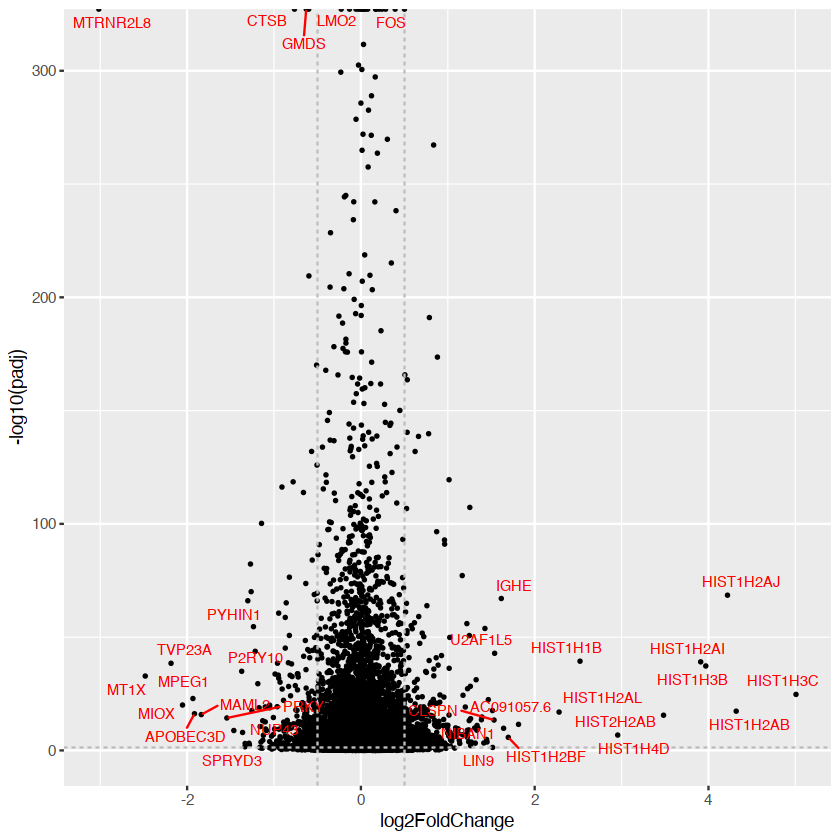

In [18]:
td <- VolcanoPlot(DE_scSHM)
td

In [19]:
DE_scSHM %>% filter(rowname == "LTB")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
LTB,0.9018892,0.8369286,NA,186.5971,2.926629e-270,6.047792e-268


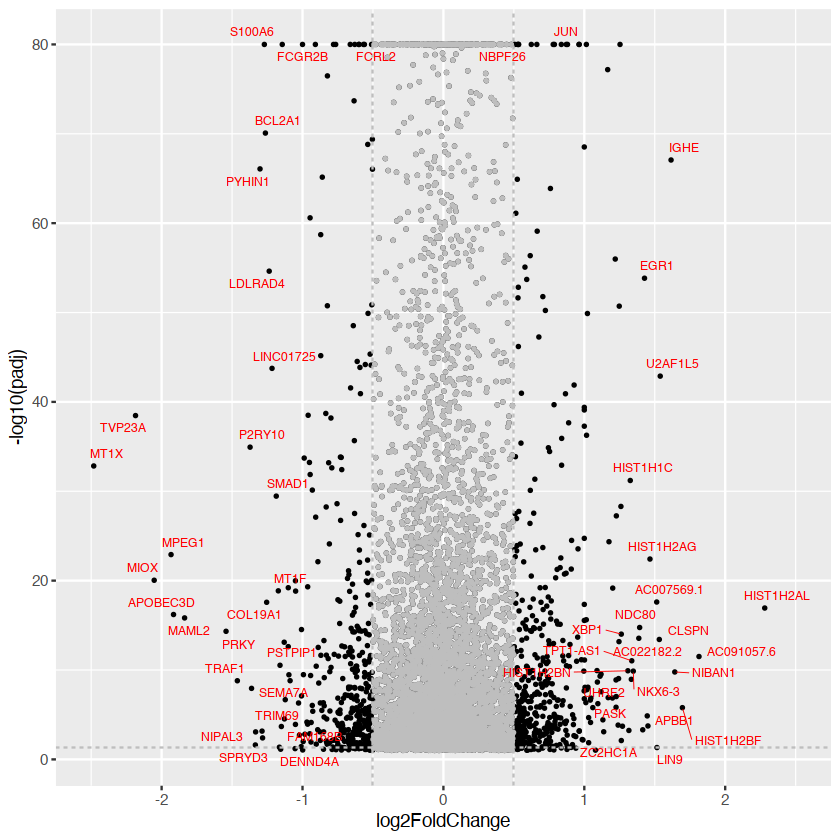

In [20]:
tc <- VolcanoPlotFixedFrame(DE_scSHM)
tc

In [21]:
#fig_save(td , filename = ("figs_paper/volcano_plot"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

If within a row, all samples have zero counts, the baseMean column will be zero, and the log2 fold change estimates, p value and adjusted p value will all be set to NA.
If a row contains a sample with an extreme count outlier then the p value and adjusted p value will be set to NA. These outlier counts are detected by Cook’s distance. Customization of this outlier filtering and description of functionality for replacement of outlier counts and refitting is described below
If a row is filtered by automatic independent filtering, for having a low mean normalized count, then only the adjusted p value will be set to NA. Description and customization of independent filtering is described below

# Pathway analysis

### Convert genes names to Entrez Gene

In [22]:
DE_scSHM$entrez = mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="ENTREZID",
                     keytype="SYMBOL",
                     multiVals="first")
DE_scSHM$name =   mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="GENENAME",
                     keytype="SYMBOL",
                     multiVals="first")

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



In [23]:
## Remove any NA values (reduces the data by quite a bit)
DE_scSHM <- dplyr::filter(DE_scSHM, entrez != "NA")

## Remove any Entrez duplicates
DE_scSHM <- DE_scSHM[which(duplicated(DE_scSHM$entrez) == F), ]

In [24]:
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
NOC2L,0.22709129,-0.07331567,NA,9.503145,4.115244e-13,1.424321e-12,26155,NOC2 like nucleolar associated transcriptional repressor
ISG15,0.08298455,-0.08865707,NA,13.353169,3.116654e-19,1.531301e-18,9636,ISG15 ubiquitin like modifier
SDF4,0.29567413,0.70771890,NA,12.680680,3.706971e-18,1.721426e-17,51150,stromal cell derived factor 4
UBE2J2,0.25988836,0.04313786,NA,10.695725,5.362207e-15,2.080335e-14,118424,ubiquitin conjugating enzyme E2 J2
INTS11,0.27118955,-0.03704905,NA,6.142462,6.683340e-08,1.574686e-07,54973,integrator complex subunit 11
CPTP,0.10802095,0.08809156,NA,3.057653,1.957757e-03,2.878259e-03,80772,ceramide-1-phosphate transfer protein


In [25]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AICDA,0.1137483,0.6168524,NA,21.13516,9.529849e-32,7.89584e-31,57379,activation induced cytidine deaminase


### List of DNA repair genes

In [26]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [27]:
# number of genes analysed
length(genes_names$gene)

[1] 66

In [28]:
DE_scSHM %>% filter(rowname %in% genes_names$gene, padj > 0.05)  %>% arrange(rowname) 

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
APEX2,0.11922147,-0.23632413,NA,0.6751031,0.71395846,0.72363995,27301,apurinic/apyrimidinic endodeoxyribonuclease 2
APTX,0.13395494,0.32299189,NA,1.4185143,0.18312489,0.20204703,54840,aprataxin
NTHL1,0.05249024,0.41835935,NA,1.5158926,0.14600644,0.16358495,4913,nth like DNA glycosylase 1
PARP2,0.05321493,0.01804723,NA,1.6095568,0.11655009,0.13248357,10038,poly(ADP-ribose) polymerase 2
PARP4,0.09238713,-0.17835369,NA,1.0669624,0.38319850,0.40232407,143,poly(ADP-ribose) polymerase family member 4
PMS1,0.13781211,-0.31099738,NA,1.9895447,0.04387194,0.05315473,5378,"PMS1 homolog 1, mismatch repair system component"
POLB,0.06155173,0.32676733,NA,1.2125511,0.28700687,0.30702044,5423,DNA polymerase beta
SMUG1,0.06866994,-0.14450276,NA,1.6294349,0.11101024,0.12655491,23583,single-strand-selective monofunctional uracil-DNA glycosylase 1
XRCC1,0.14256744,0.29296931,NA,1.6968801,0.09389979,0.10818955,7515,X-ray repair cross complementing 1


In [29]:
DE_scSHM %>% filter(rowname %like% "POLG")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
POLG,0.08994437,-0.1006446,NA,0.9399607,0.4818765,0.4992869,5428,"DNA polymerase gamma, catalytic subunit"
POLG2,0.08374239,0.3225603,NA,0.9102828,0.5066257,0.5230790,11232,"DNA polymerase gamma 2, accessory subunit"


## 1) Generally Applicable Gene-set Enrichment for Pathway Analysis: gage

In [30]:
kegg.sets.hs = kegg.sets.hs[sigmet.idx.hs]

In [31]:
# pathways not related with B cells
unvaluable_pathway <- c("hsa04966 Collecting duct acid secretion","hsa04971 Gastric acid secretion","hsa04914 Progesterone-mediated oocyte maturation",
                        "hsa04720 Long-term potentiation","hsa04916 Melanogenesis", "hsa04260 Cardiac muscle contraction",
                       "hsa04270 Vascular smooth muscle contraction","hsa04114 Oocyte meiosis","hsa04972 Pancreatic secretion","hsa04730 Long-term depression")

In [32]:
#remove those pathways from the list genes
kegg.sets.hs_filter <- discard(kegg.sets.hs, (names(kegg.sets.hs) %in% unvaluable_pathway ))

In [33]:
## Extract the foldchanges
foldchanges = DE_scSHM$log2FoldChange

## Name each fold change with the corresponding Entrez ID
names(foldchanges) = DE_scSHM$entrez
head(foldchanges)

26155        9636       51150      118424       54973       80772 
-0.07331567 -0.08865707  0.70771890  0.04313786 -0.03704905  0.08809156

In [34]:
## Sort fold changes in decreasing order
foldchanges <- sort(foldchanges, decreasing = TRUE)

In [35]:
saveRDS(foldchanges, file = "foldchanges.rds")

In [36]:
# Get the results
keggres = gage(foldchanges, gsets=kegg.sets.hs_filter, same.dir=TRUE)

# Look at both up (greater), down (less), and statatistics.
lapply(keggres, head,15)

,p.geomean,stat.mean,p.val,q.val,set.size,exp1
hsa03030 DNA replication,0.0006103335,3.4076379,0.0006103335,0.06408502,29,0.0006103335
hsa00860 Porphyrin and chlorophyll metabolism,0.0094396583,2.5126609,0.0094396583,0.41745723,14,0.0094396583
hsa03430 Mismatch repair,0.0119273493,2.3573081,0.0119273493,0.41745723,20,0.0119273493
hsa04110 Cell cycle,0.0464738830,1.6891036,0.0464738830,0.95890600,91,0.0464738830
hsa00670 One carbon pool by folate,0.0563957734,1.6524646,0.0563957734,0.95890600,12,0.0563957734
hsa00240 Pyrimidine metabolism,0.0624069348,1.5456149,0.0624069348,0.95890600,62,0.0624069348
hsa03410 Base excision repair,0.0888428550,1.3658501,0.0888428550,0.95890600,28,0.0888428550
hsa00230 Purine metabolism,0.0892693644,1.3515165,0.0892693644,0.95890600,77,0.0892693644
hsa04115 p53 signaling pathway,0.1852526160,0.9003251,0.1852526160,0.95890600,44,0.1852526160
hsa00760 Nicotinate and nicotinamide metabolism,0.2033231925,0.8517406,0.2033231925,0.95890600,10,0.2033231925


In [37]:
# Get the pathways
keggrespathways = data.frame(id=rownames(keggres$greater), keggres$greater) %>% 
  tbl_df() %>% 
  filter(row_number()<=5) %>% 
  .$id %>% 
  as.character()
keggrespathways

[1] "hsa03030 DNA replication"                     
[2] "hsa00860 Porphyrin and chlorophyll metabolism"
[3] "hsa03430 Mismatch repair"                     
[4] "hsa04110 Cell cycle"                          
[5] "hsa00670 One carbon pool by folate"

In [38]:
# Get the IDs.
keggresids = substr(keggrespathways, start=1, stop=8)
keggresids

[1] "hsa03030" "hsa00860" "hsa03430" "hsa04110" "hsa00670"

In [39]:
# # Define plotting function for applying later
# plot_pathway = function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa", new.signature=FALSE)

# # plot multiple pathways (plots saved to disk and returns a throwaway list object)
# tmp = sapply(keggresids, function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa")) #kegg.native = F, same.layer = F

### 2) Gene Set Enrichment Analysis (GSEA) : fgsea tool

- Subset:
    - C2: curated gene sets: 	Gene sets in this collection are curated from various sources, including online pathway databases and the biomedical literature. Many sets are also contributed by individual domain experts. The gene set page for each gene set lists its source. The C2 collection is divided into the following two sub-collections: Chemical and genetic perturbations (CGP) and Canonical pathways (CP).
        - KEGG subset of CP (186 gene sets) = Canonical Pathways gene sets derived from the KEGG pathway database.
    - H: hallmark gene sets (50 gene sets) = Hallmark gene sets summarize and represent specific well-defined biological states or processes and display coherent expression. These gene sets were generated by a computational methodology based on identifying overlaps between gene sets in other MSigDB collections and retaining genes that display coordinate expression

In [40]:
# create list with all gene sets
gs <-
  lapply( list.files( "../SHM_in_the_act/input/msigdb_v2022.1.Hs_files_to_download_locally/msigdb_v2022.1.Hs_GMTs/" ),
            function( f ){
              qusage::read.gmt( paste0( "../SHM_in_the_act/input/msigdb_v2022.1.Hs_files_to_download_locally/msigdb_v2022.1.Hs_GMTs/", f ) )
            }
  ) %>%
  setNames( list.files( "../SHM_in_the_act/input/msigdb_v2022.1.Hs_files_to_download_locally/msigdb_v2022.1.Hs_GMTs/" ) )

# create rank: named vector       

r <- DE_scSHM$log2FoldChange %>% setNames( DE_scSHM$rowname )


# loop gene set collections
p <-
  rbindlist(
    lapply( names( gs ) %>% .[. %like% "c2.cp.kegg.v2022.1.Hs.symbols" ], #"h.all.v2022.1.Hs.symbols"
              function( g ){
                fgsea::fgsea(
                  # .gmt with pathways to analyzed
                  pathways = gs[[ g ]],
                  # my ranked list
                  stats    = r,
                  # min size of the gene set
                  minSize = 10,
                  # max size of the gene set
                  maxSize = 750,
                  eps = 0
                ) %>%
                  # add gene set name
                  mutate( gs = g ) %>%
                  filter( padj < 0.1 ) 

              } ) )
      

In [41]:
path <- gs[[names( gs ) %>% .[. %like% "c2.cp.kegg.v2022.1.Hs.symbols" ]]]

In [42]:
p %>% filter(padj <= 0.05) %>% arrange(-NES)

pathway,pval,padj,log2err,ES,NES,size,leadingEdge,gs
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>,<chr>
KEGG_DNA_REPLICATION,2.264462e-06,0.0003170246,0.6272567,0.6973492,2.221786,29,"FEN1, MC....",c2.cp.kegg.v2022.1.Hs.symbols.gmt
KEGG_PORPHYRIN_AND_CHLOROPHYLL_METABOLISM,1.934261e-04,0.0135398289,0.5188481,0.7696935,1.981534,13,"COX10, H....",c2.cp.kegg.v2022.1.Hs.symbols.gmt
KEGG_MISMATCH_REPAIR,9.751501e-04,0.0349898326,0.4772708,0.6630898,1.920368,20,"RFC4, ML....",c2.cp.kegg.v2022.1.Hs.symbols.gmt
KEGG_PYRIMIDINE_METABOLISM,9.997095e-04,0.0349898326,0.4550599,0.4556659,1.695432,62,"PNP, TYM....",c2.cp.kegg.v2022.1.Hs.symbols.gmt


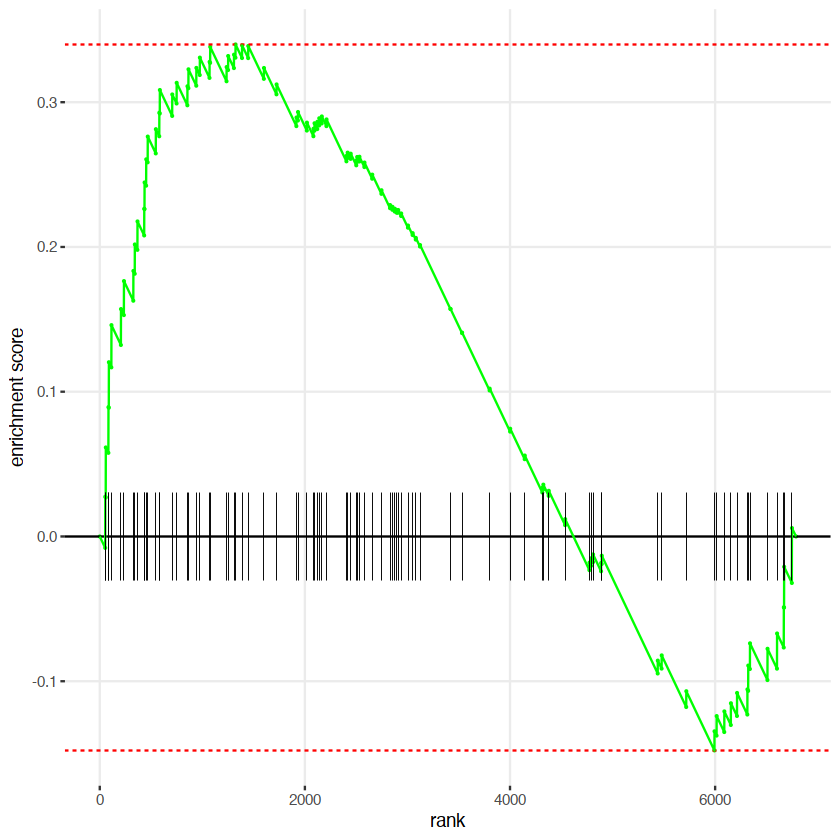

In [43]:
fgsea::plotEnrichment(path[["KEGG_CELL_CYCLE"]], r) 

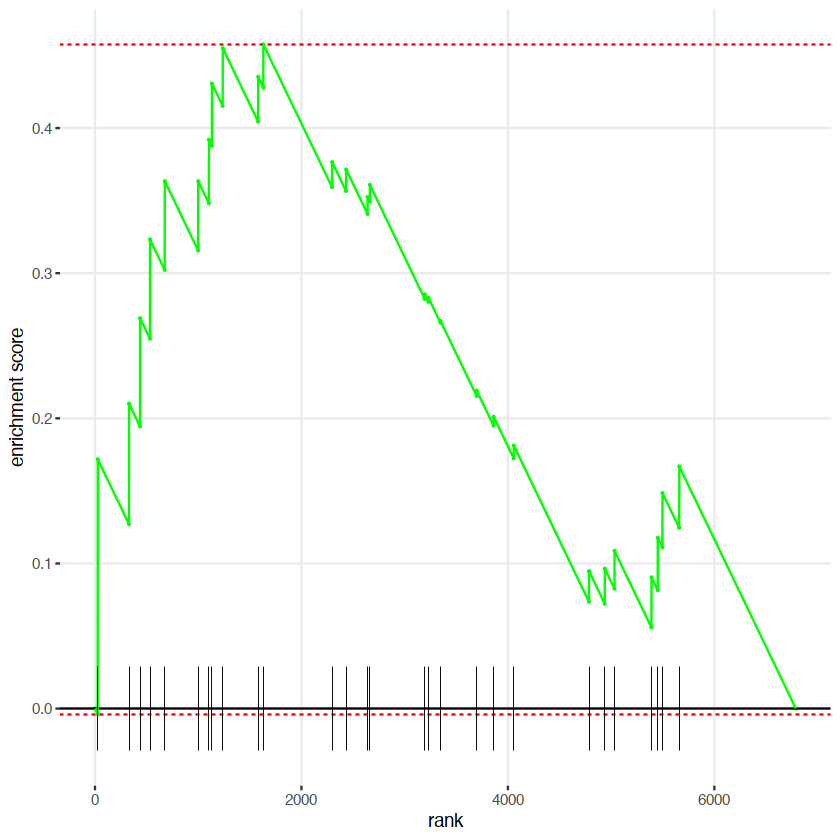

In [44]:
fgsea::plotEnrichment(path[["KEGG_BASE_EXCISION_REPAIR"]], r) 

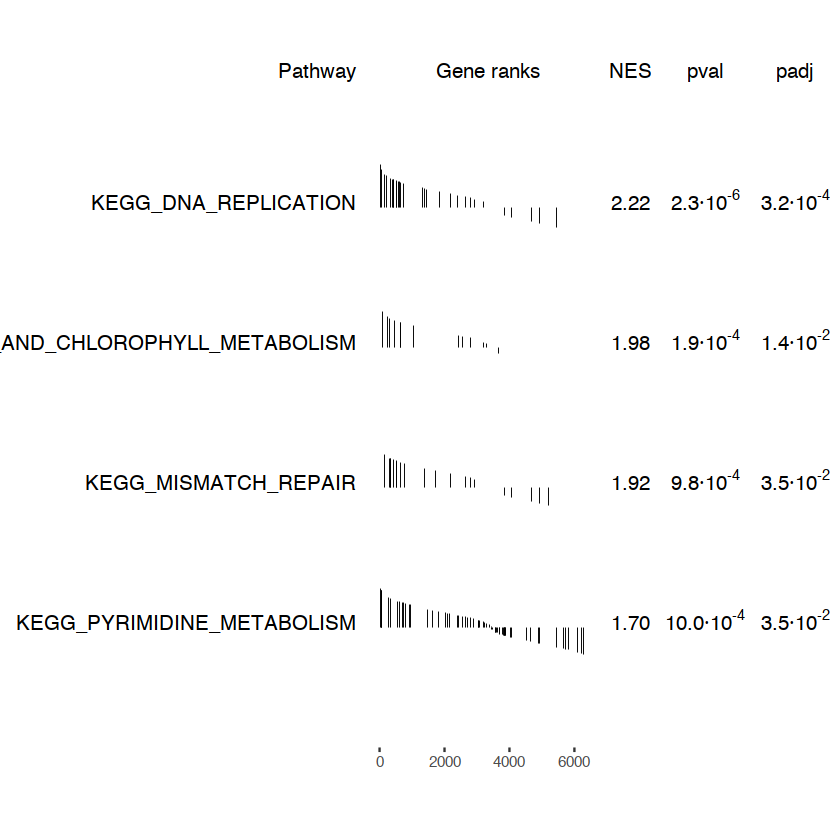

In [45]:
topPathways <- p %>% 
    top_n(20, wt=-padj) %>% 
    arrange(-NES) %>% 
    pull(pathway)

fgsea::plotGseaTable(path[topPathways], 
              r, 
              p, 
              gseaParam = 0.5)

## 3) KEGG Enrichment Analysis of a gene set : Cluster profiler tool

In [46]:
kegg_organism = "hsa"
kk2 = gseKEGG(geneList     = foldchanges,
               organism     = kegg_organism,
               minGSSize    = 3,
               maxGSSize    = 800,
               pvalueCutoff = 0.05,
               pAdjustMethod = "none",
               keyType       = "ncbi-geneid")

Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...

Reading KEGG annotation online: "https://rest.kegg.jp/conv/ncbi-geneid/hsa"...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



In [47]:
kk2@result %>% filter(p.adjust <= 0.05) %>% arrange(-NES,qvalue) %>% head(.,11) #filter(Description %in% c("Histidine metabolism"))#

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
hsa03030,hsa03030,DNA replication,29,0.6973492,2.225359,5.726691e-06,5.726691e-06,0.001928991,750,"tags=48%, list=11%, signal=43%",2237/4176/5984/4171/10714/246243/4172/5111/5982/3978/4173/23649/5985/4175
hsa03430,hsa03430,Mismatch repair,20,0.6630898,1.958298,4.982023e-04,4.982023e-04,0.083907760,776,"tags=45%, list=11%, signal=40%",5984/4292/4436/10714/5111/5982/3978/5985/4437
hsa00860,hsa00860,Porphyrin metabolism,13,0.6830523,1.804998,4.906994e-03,4.906994e-03,0.275480386,1051,"tags=54%, list=15%, signal=46%",1352/3052/3163/2990/5498/644/211
hsa01524,hsa01524,Platinum drug resistance,47,0.4974503,1.770206,2.410463e-03,2.410463e-03,0.202986322,1153,"tags=43%, list=17%, signal=36%",5429/672/27113/2944/7153/7155/4292/4436/317/842/4259/7507/207/4437/4193/1026/5980/208/331/596
hsa03460,hsa03460,Fanconi anemia pathway,30,0.5119316,1.663018,1.467039e-02,1.467039e-02,0.483473768,988,"tags=37%, list=15%, signal=31%",641/5429/672/7398/2188/4292/29089/8940/2175/5980/55215
hsa00670,hsa00670,One carbon pool by folate,12,0.6402402,1.644669,1.606048e-02,1.606048e-02,0.483473768,1542,"tags=58%, list=23%, signal=45%",7298/1719/4522/6470/123263/6472/441024
hsa03440,hsa03440,Homologous recombination,26,0.5140246,1.607694,1.980104e-02,1.980104e-02,0.483473768,858,"tags=31%, list=13%, signal=27%",641/672/10714/580/79184/51720/5932/8940
hsa03410,hsa03410,Base excision repair,38,0.4643161,1.577084,1.755757e-02,1.755757e-02,0.483473768,1631,"tags=45%, list=24%, signal=34%",2237/5984/10714/5111/5982/3978/5985/4913/5423/54840/11232/79661/7515/7374/5983/27343/8930
hsa01232,hsa01232,Nucleotide metabolism,47,0.4389758,1.562121,1.551175e-02,1.551175e-02,0.483473768,940,"tags=21%, list=14%, signal=18%",4860/7298/51251/6241/132/1841/8623/7083/8833/1503


In [48]:
kk2@result %>% filter(Description == "Base excision repair")

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
hsa03410,hsa03410,Base excision repair,38,0.4643161,1.577084,0.01755757,0.01755757,0.4834738,1631,"tags=45%, list=24%, signal=34%",2237/5984/10714/5111/5982/3978/5985/4913/5423/54840/11232/79661/7515/7374/5983/27343/8930


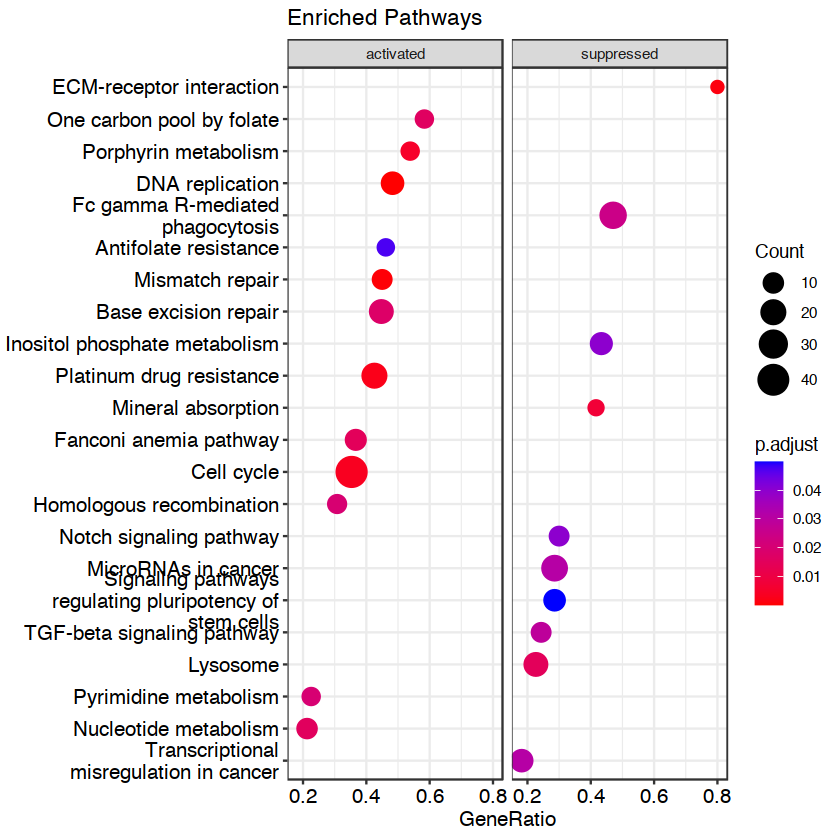

In [49]:
da <- dotplot(kk2, showCategory = 20, title = "Enriched Pathways" , split=".sign") + facet_grid(.~.sign)
da

In [50]:
selected_pathways <- c("DNA replication","Fanconi anemia pathway","Mismatch repair", "Cell cycle",#neg
                       "Rheumatoid arthritis","NF-kappa B signaling pathway","JAK-STAT signaling pathway",
                      "Cytokine-cytokine receptor interaction","NOD-like receptor signaling pathway","Transcriptional misregulation in cancer",
                      "Base excision repair","Fc gamma R-mediated phagocytosis","MicroRNAs in cancer","Lysosome",
                       "TGF-beta signaling pathway", "ECM-receptor interaction","Platinum drug resistance") #pos

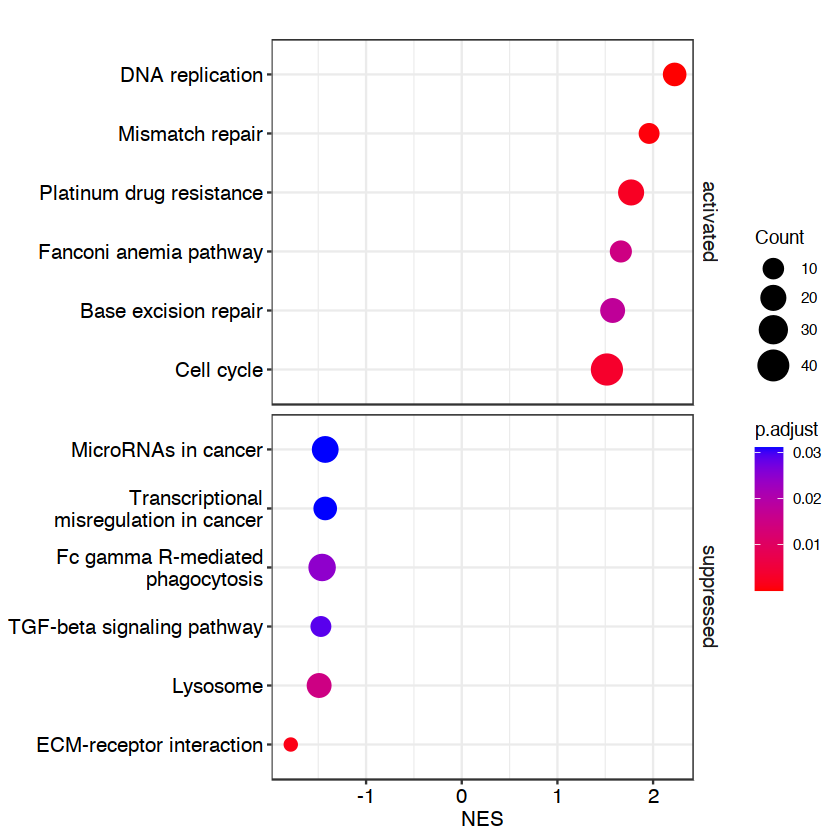

In [51]:
dt <- dotplot(kk2, x= "NES", showCategory = selected_pathways , split=".sign") + facet_grid(.sign~.,scales = "free")+
#  theme_bw() +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

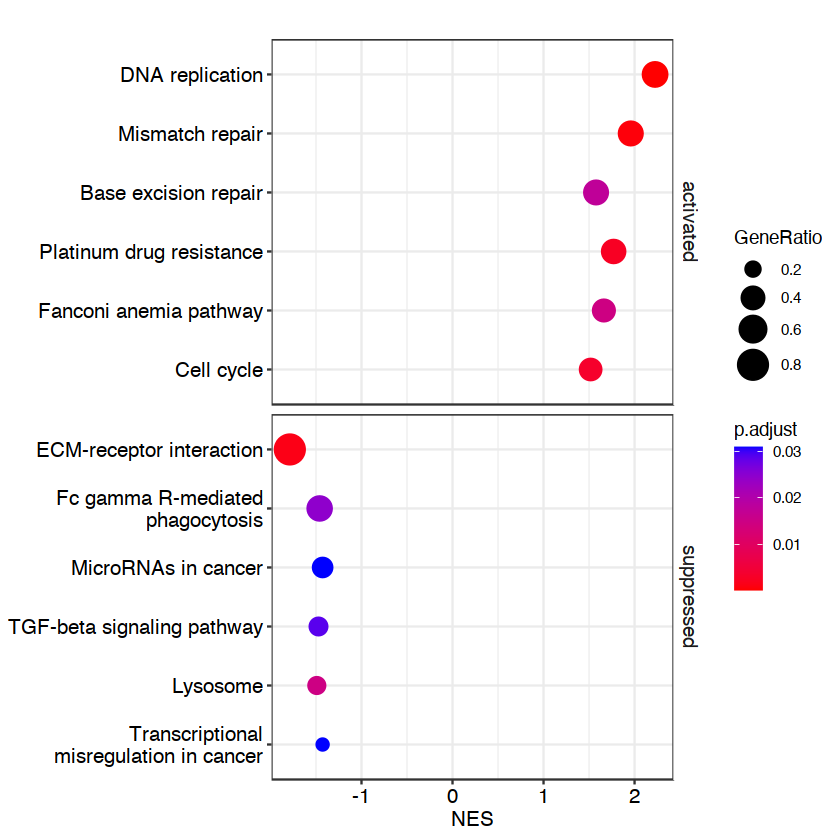

In [52]:
dt <- dotplot(kk2,x= "NES", size = "GeneRatio",showCategory = selected_pathways , split=".sign", orderBy = "GeneRatio") + facet_grid(.sign~.,scales = "free")+
#  theme_bw() +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

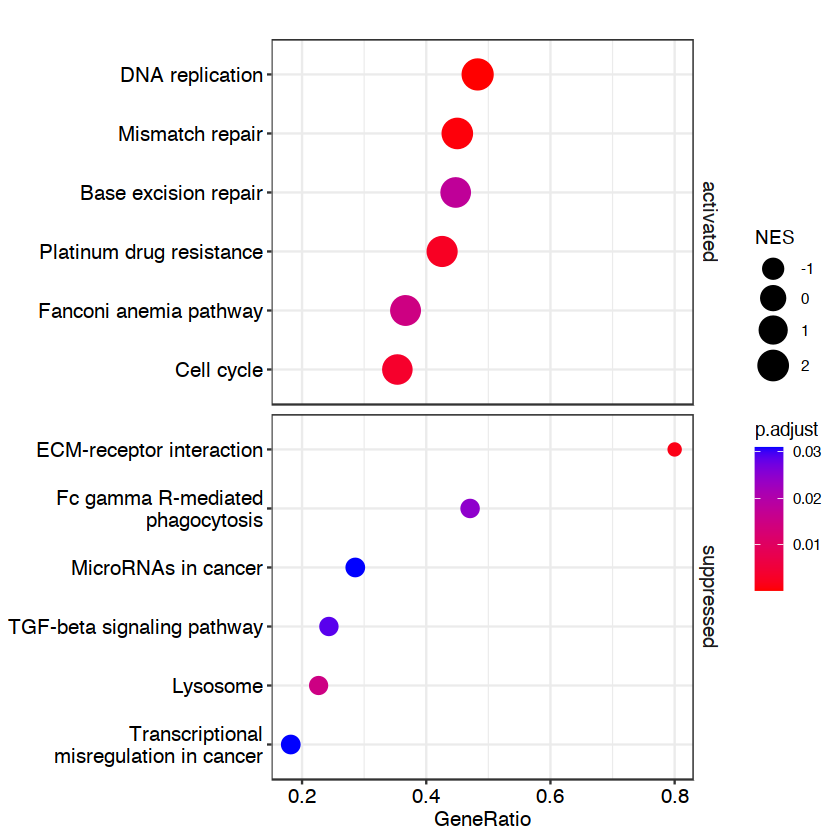

In [53]:
dt <- dotplot(kk2,x= "GeneRatio", size ="NES" ,showCategory = selected_pathways , split=".sign", orderBy = "GeneRatio") + facet_grid(.sign~.,scales = "free")+
#  scale_size_continuous(range = c(-1,2.2), breaks = seq(-1, 2.2, by = 0.8)) +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

In [54]:
fig_save(dt , filename = ("figs_paper/dotplot_pathways_NES"), formats = c("pdf", "png"), width = 15, height= 20, units = "cm", dpi = 320)

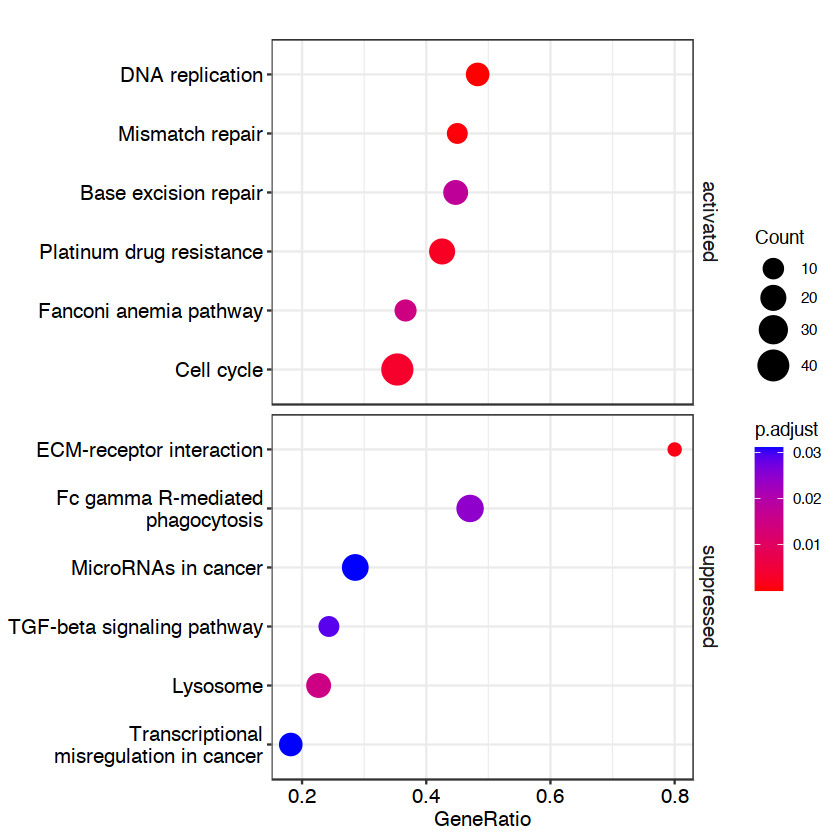

In [55]:
dt <- dotplot(kk2, showCategory = selected_pathways , split=".sign") + facet_grid(.sign~.,scales = "free")+
#  theme_bw() +
  theme(strip.text = element_text(
    size = 12),strip.background = element_rect(fill = "white", colour = NA),) 
dt

In [56]:
#fig_save(dt , filename = ("figs_paper/dotplot_pathways"), formats = c("pdf", "png"), width = 15, height =20, units = "cm", dpi = 320)

In [57]:
# # Get the pathways
# keggrespathways = kk2 %>% 
#   tbl_df() %>% 
# #  filter(Description %in% selected_pathways, ID != 'hsa01100') %>% 
#   filter(row_number()<=5) %>%
#   .$ID %>% 
#   as.character()
# keggrespathways

In [58]:
# Get the IDs.
# keggresids = substr(keggrespathways, start=1, stop=8)
# keggresids

keggresids = c("hsa03030","hsa03460","hsa03430","hsa03410")
keggresids

[1] "hsa03030" "hsa03460" "hsa03430" "hsa03410"

In [59]:
# Define plotting function for applying later
plot_pathway = function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa", new.signature=FALSE)

# plot multiple pathways (plots saved to disk and returns a throwaway list object)
tmp = sapply(keggresids, function(pid) pathview(gene.data=foldchanges, pathway.id=pid, species="hsa",
                                                limit= 2, #limit= list(gene=max(abs(foldchanges)), cpd=1),
                                               na.col ="grey",
                                                   low=list(gene="#ffa700"),
                                                    mid=list(gene="#4ac4aa"),
                                                    high=list(gene="#198bdc"))) #kegg.native = F, same.layer = F

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulveda@umag.cl/My Drive/bioinformatics/data_analysis/SHM_in_the_act

Info: Writing image file hsa03030.pathview.png

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulveda@umag.cl/My Drive/bioinformatics/data_analysis/SHM_in_the_act

Info: Writing image file hsa03460.pathview.png

Info: some node width is different from others, and hence adjusted!

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulveda@umag.cl/My Drive/bioinformatics/data_analysis/SHM_in_the_act

Info: Writing image file hsa03430.pathview.png

'select()' returned 1:1 mapping between keys and columns

Info: Working in directory /Users/julieta/Library/CloudStorage/GoogleDrive-julieta.sepulve

#### generate a df from every pathway of interest

In [60]:
# #pathways
# paths <-c("KEGG_CELL_CYCLE","KEGG_MAPK_SIGNALING_PATHWAY")#,"VEGF signaling pathway",
# #          "Ribosome", "Antigen processing and presentation", "Cytokine-cytokine receptor interaction")

# # create an empty list to store the data frames
# df_list <- list()

# for (i in paths) {
#     i$entrez <- mapIds(org.Hs.eg.db,
#                      keys=path$i, 
#                      column="ENTREZID",
#                      keytype="SYMBOL",
#                      multiVals="first") %>% data.frame() %>% pull(.)
    
#     df <- DE_scSHM %>% filter(entrez %in% i$entrez)
#     # use a unique name as the index of the list
#     df_list[[paste0("df_", i)]] <- df
# }

In [61]:
# #pathways
# paths <-c("KEGG_CELL_CYCLE","KEGG_MAPK_SIGNALING_PATHWAY")

# KEGG_CELL_CYCLE$entrez <- mapIds(org.Hs.eg.db,
#                      keys=path$KEGG_CELL_CYCLE, 
#                      column="ENTREZID",
#                      keytype="SYMBOL",
#                      multiVals="first") %>% data.frame() %>% pull(.)

# KEGG_CELL_CYCLE$entrez

# df <- DE_scSHM %>% filter(entrez %in% KEGG_CELL_CYCLE$entrez)

In [62]:
str(path$KEGG_MAPK_SIGNALING_PATHWAY)

 chr [1:267] "JUN" "MEF2C" "ELK4" "ELK1" "JUND" "GADD45B" "MAP3K20" "STMN1" ...


In [63]:
# create an empty list to store the data frames
df_list <- list()

for (i in keggresids) {
    xc <- kk2@result %>% filter(ID == i) %>% mutate(genes = gsub("/", ",", core_enrichment)) %>% pull(genes)
    my_vector <- strsplit(xc, ",")[[1]] 
    df <- DE_scSHM %>% filter(entrez %in% my_vector)
    # use a unique name as the index of the list
    df_list[[paste0("df_", i)]] <- df
}

In [64]:
# assign each data frame to a separate variable
for (i in names(df_list)) {
  assign(i, df_list[[i]])
}

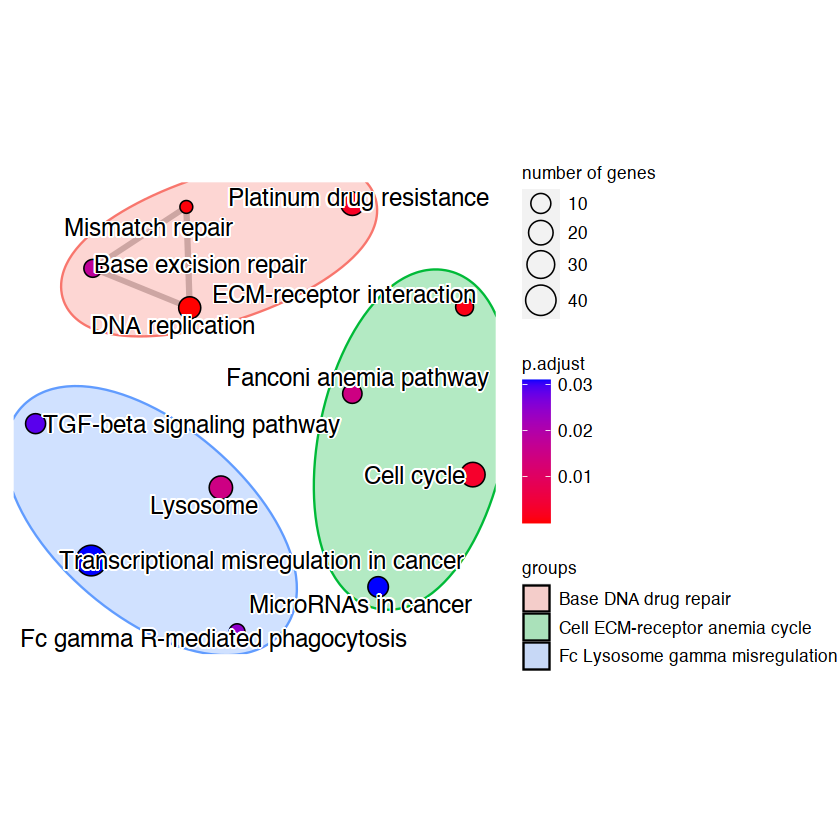

In [65]:
#set.seed(123)
x2 = pairwise_termsim(kk2)
xc <- emapplot(x2, showCategory = selected_pathways,group_category = T,group_legend = T,nCluster = 3, layaout= 'gem')
xc

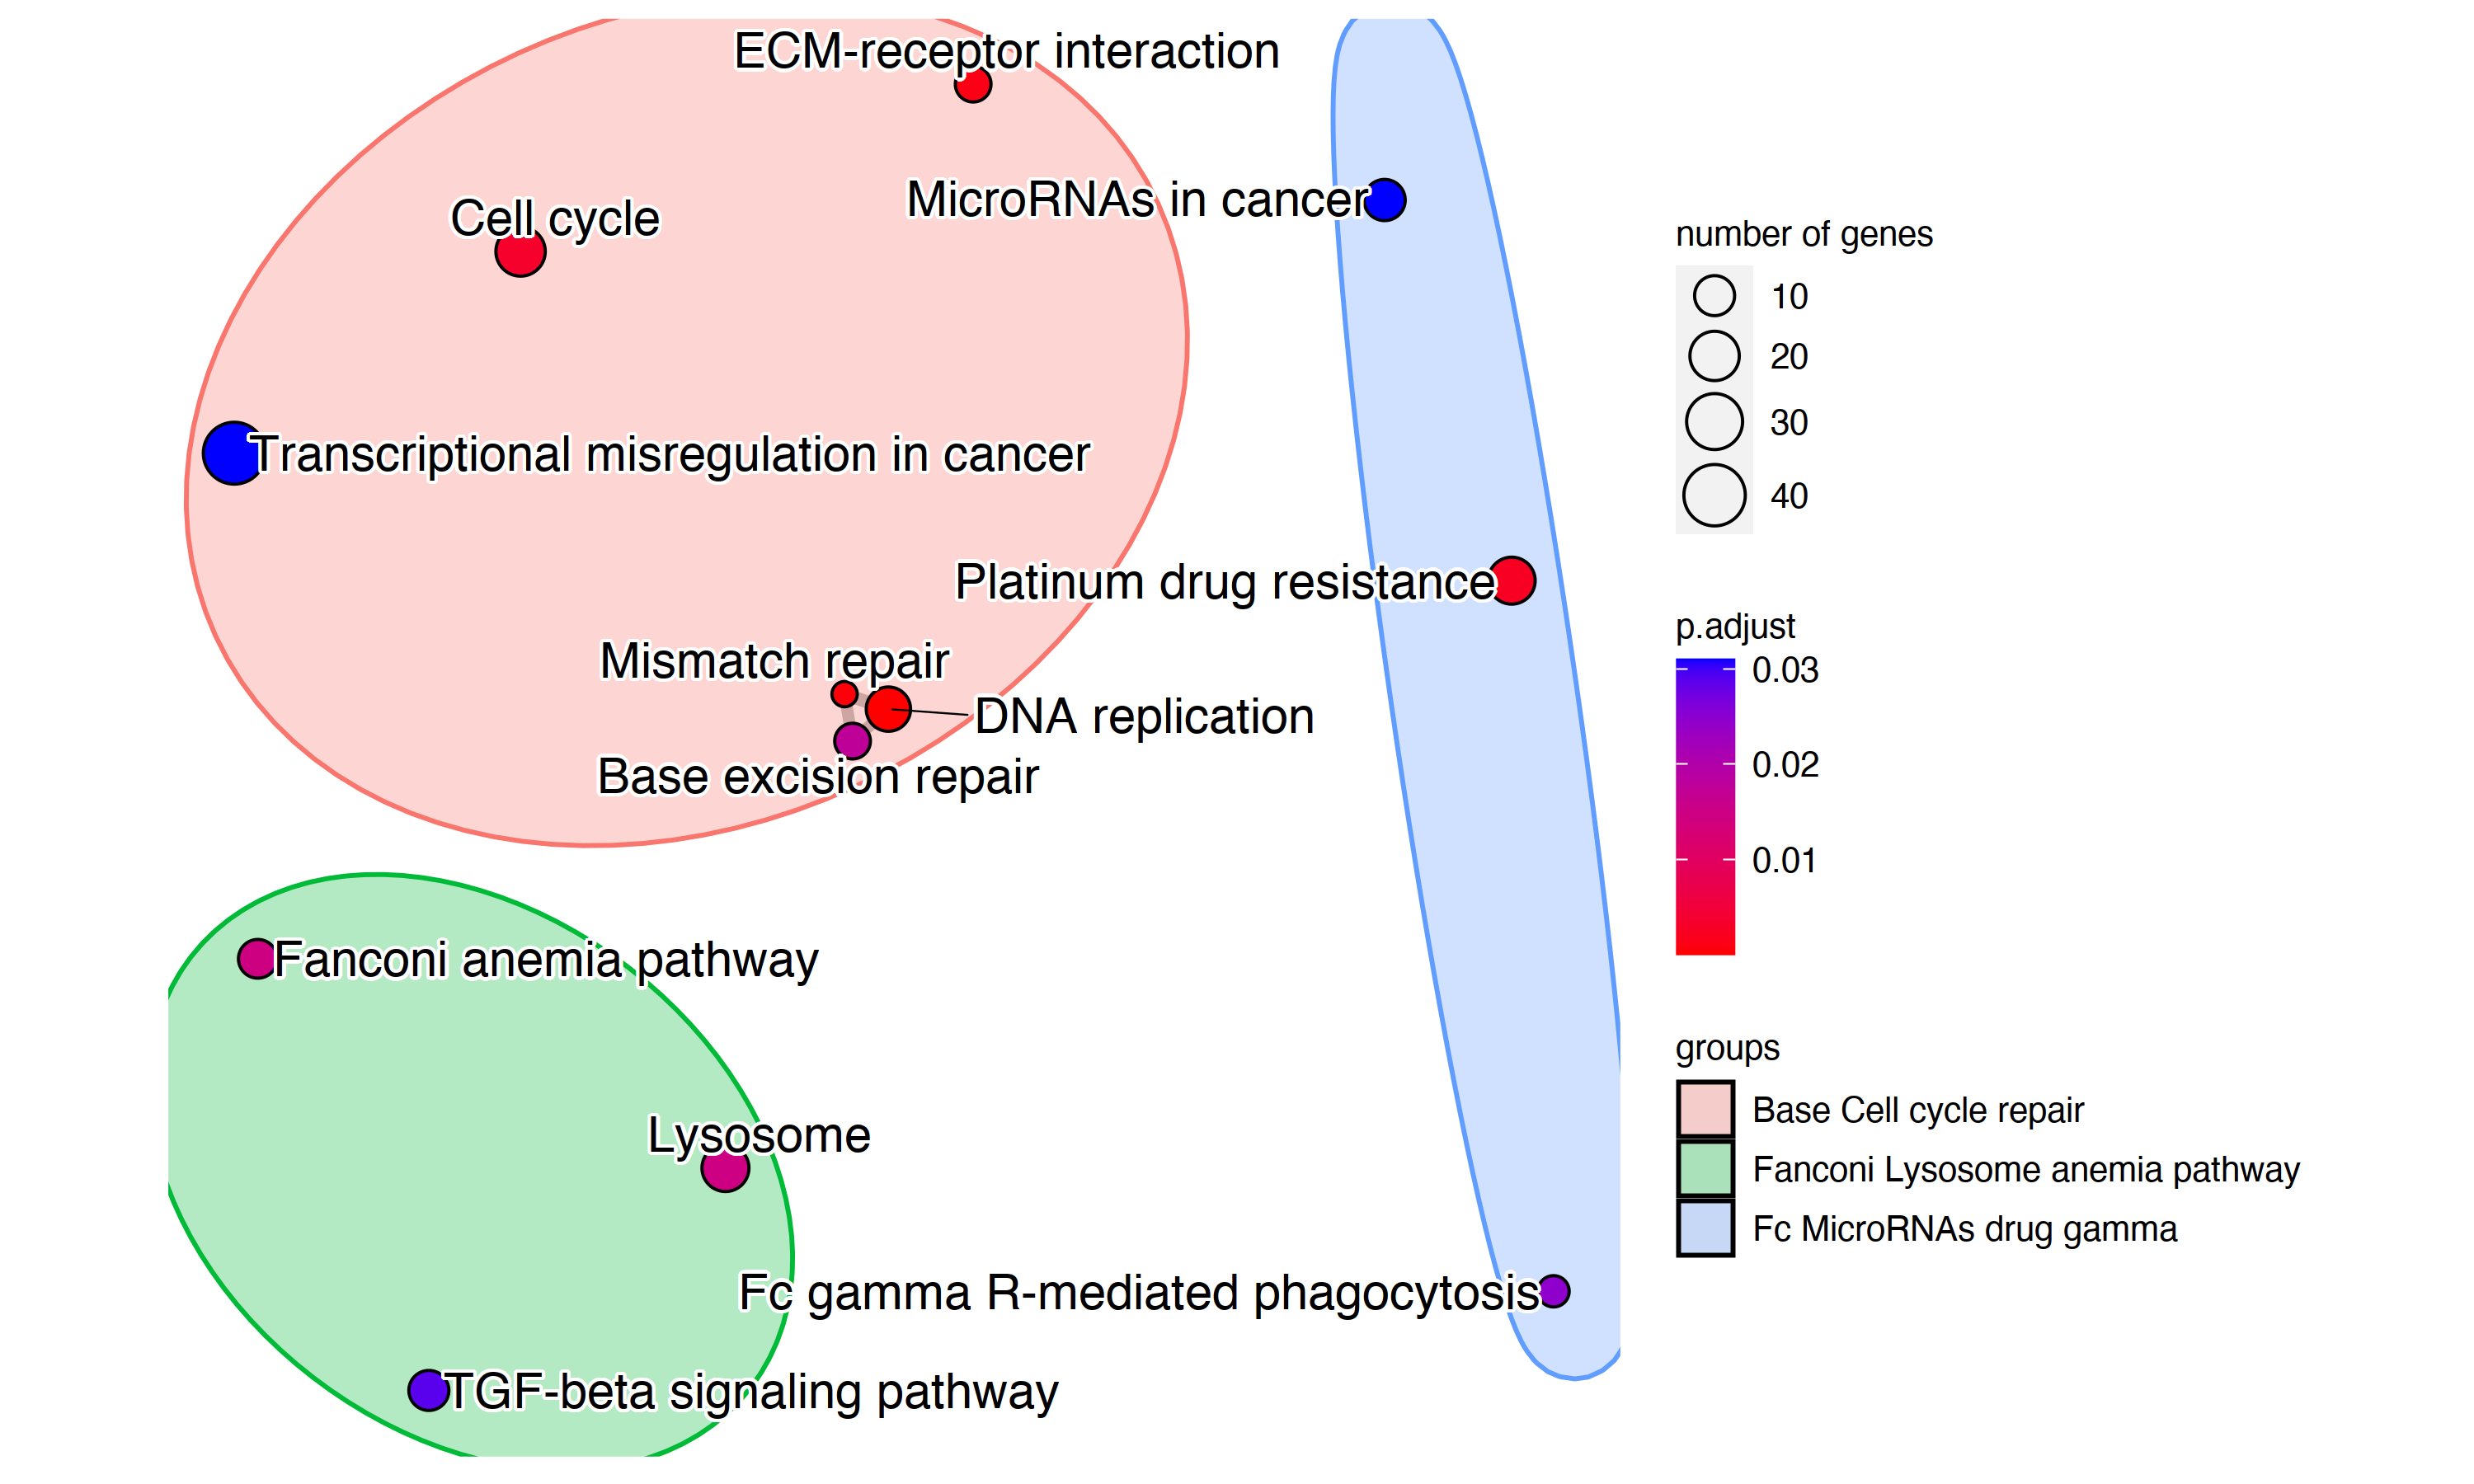

In [67]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)
#set.seed(31)
x2 = pairwise_termsim(kk2)
xc <- emapplot(
    x2,
    showCategory = selected_pathways,
    cluster.params = list(
        cluster=TRUE,
        n=3,
        legend=TRUE
    ),
    layout.params = list(
        layout = "gem"
    )
)

#pdf(file = paste0("figs_paper/emapplot.pdf"), 8.8, 5) 
print(xc) 
#dev.off()

In [68]:
fig_save(xc , filename = ("figs_paper/emapplot"), formats = c("pdf", "png"), width =20, height =20, units = "cm", dpi = 320)

Picking joint bandwidth of 0.116



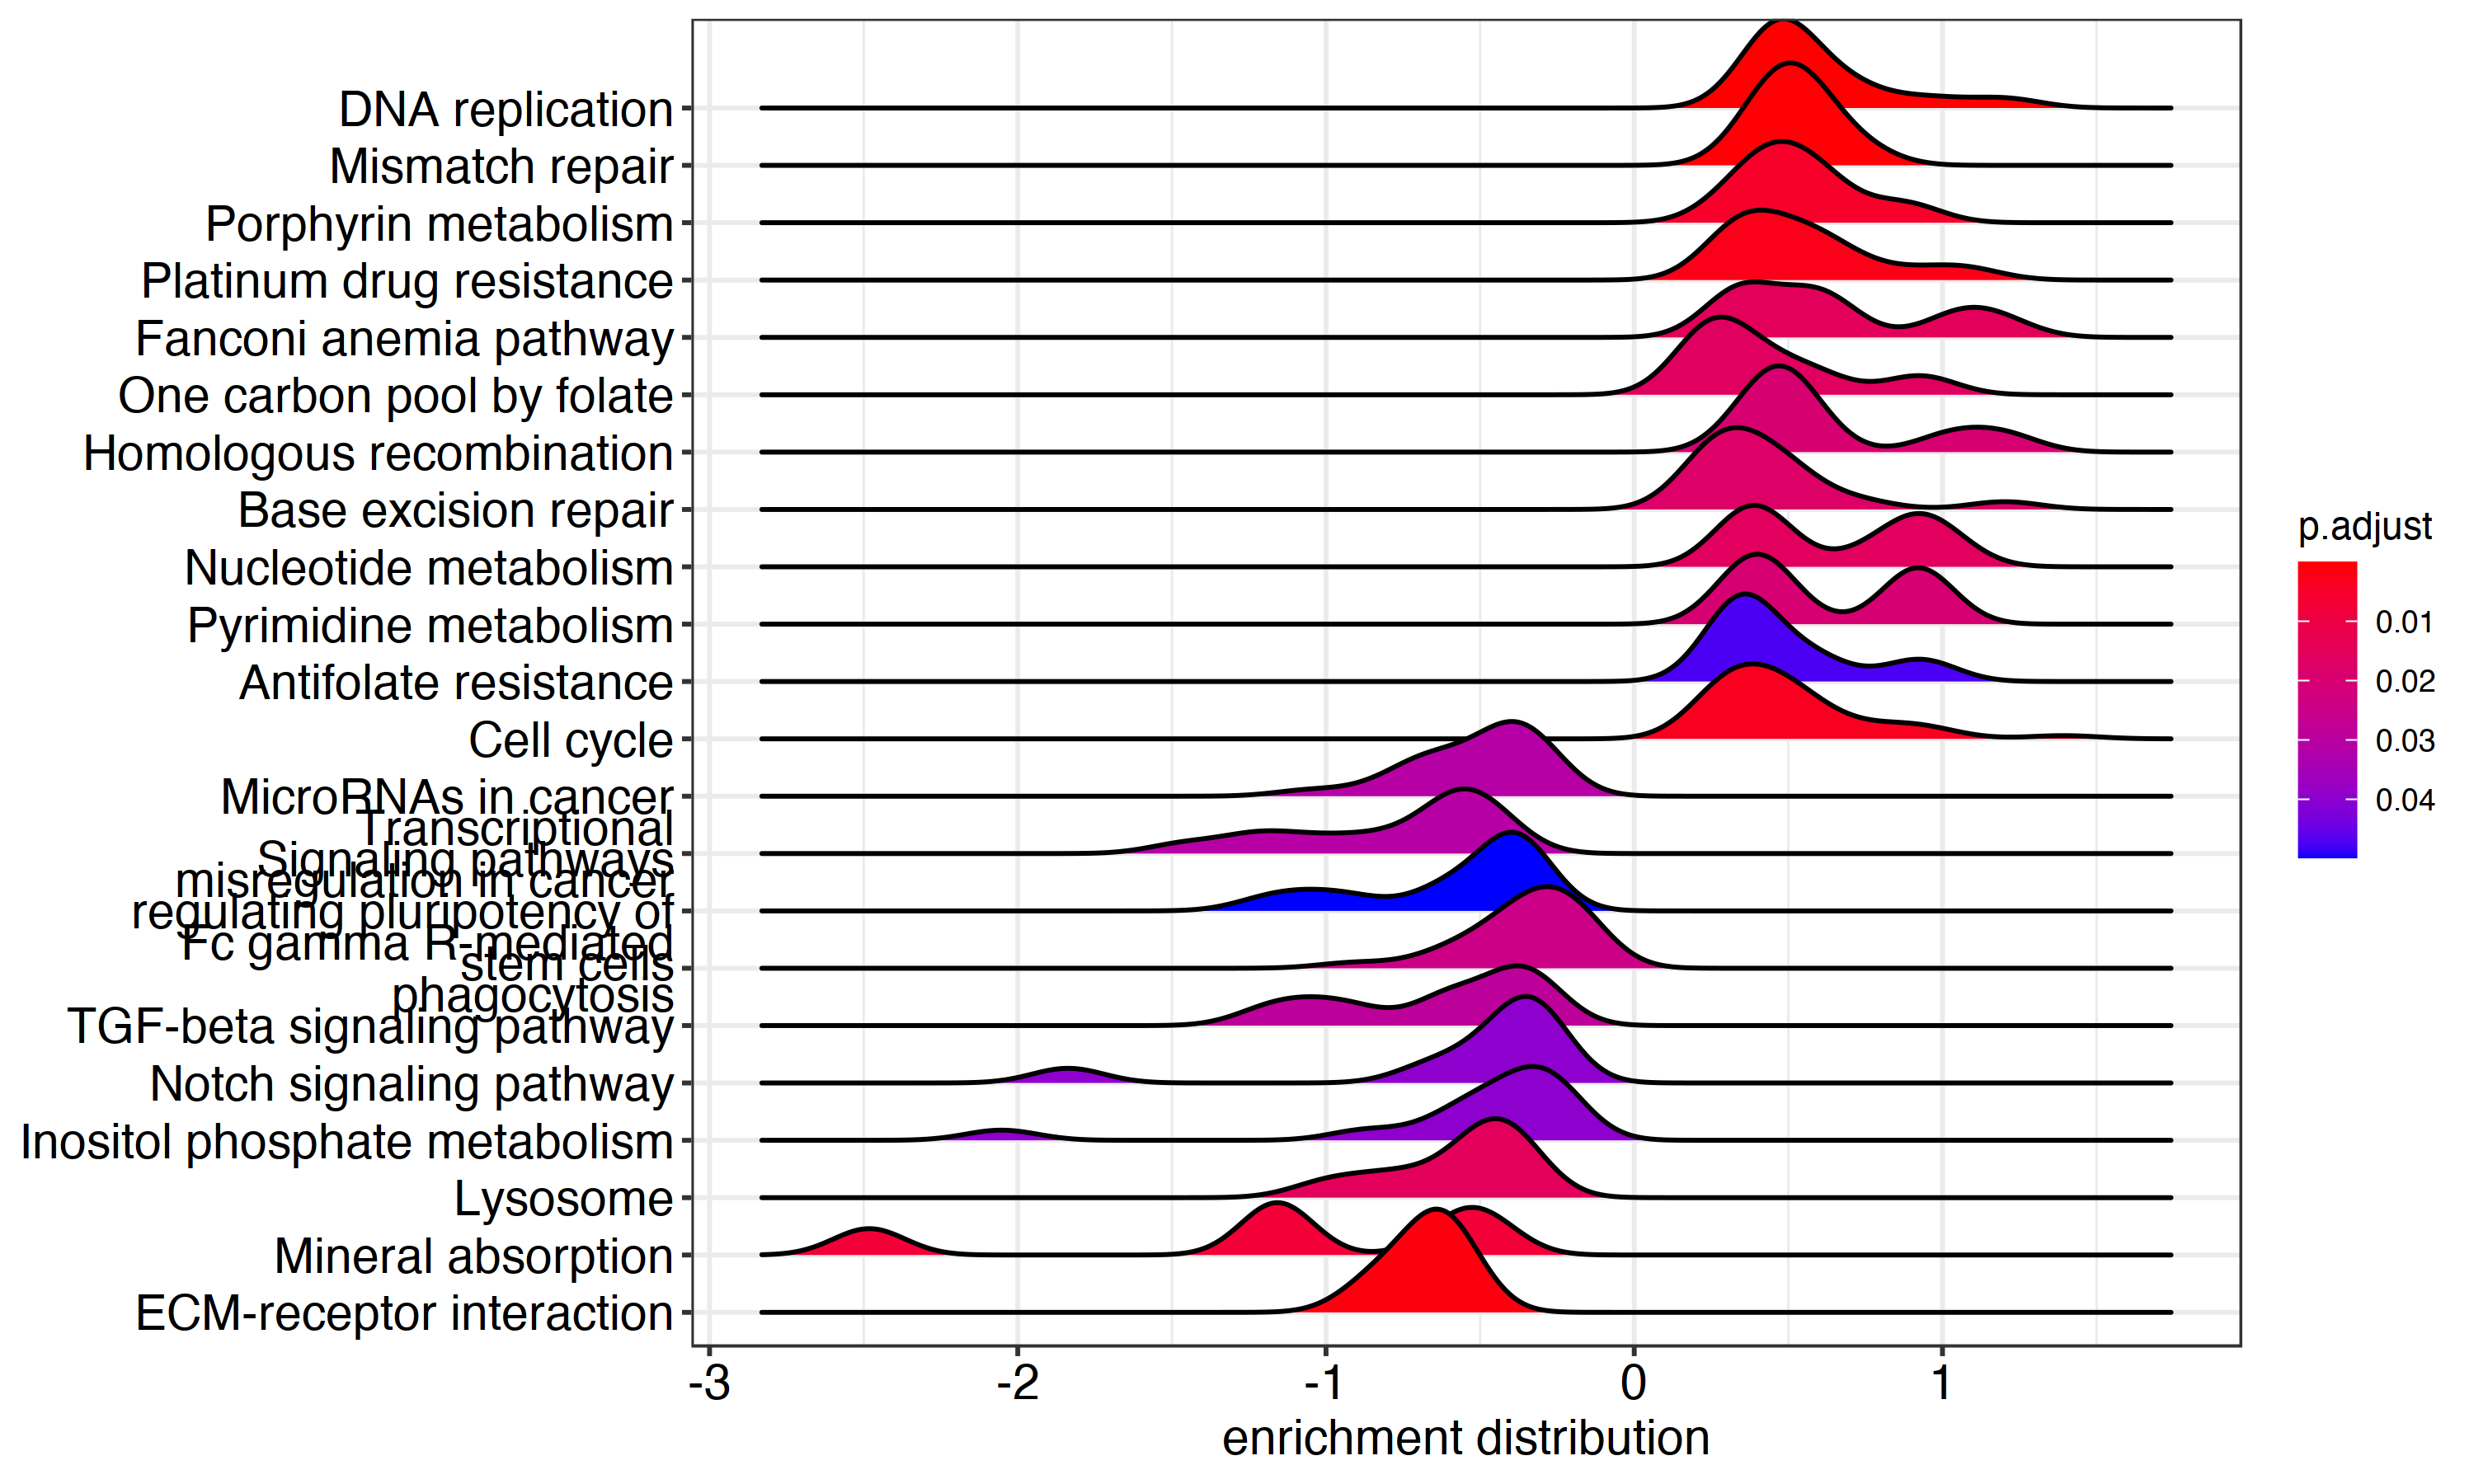

In [69]:
ridgeplot(kk2) + labs(x = "enrichment distribution")

In [70]:
library("DEGreport")

### List of DNA repair genes

In [22]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [72]:
# number of genes analysed
length(genes_names$gene)

[1] 66

In [73]:
genes_names$gene

[1] "APEX1"  "APEX2"  "APLF"   "APTX"   "CHAF1A" "CHAF1B" "ERCC6L" "FEN1"  
 [9] "HMGB1"  "HMGB2"  "LIG1"   "LIG3"   "MBD4"   "MPG"    "MUTYH"  "NEIL1" 
[17] "NEIL2"  "NEIL3"  "NTHL1"  "NUDT1"  "OGG1"   "PARP1"  "PARP2"  "PARP3" 
[25] "PARP4"  "PCNA"   "PNKP"   "POLB"   "POLD1"  "POLD2"  "POLD4"  "POLD3" 
[33] "POLE"   "POLE2"  "POLE3"  "POLE4"  "POLL"   "POLQ"   "RECQL"  "SMUG1" 
[41] "TDG"    "UNG"    "XRCC1"  "RPA1"   "EXO1"   "MLH1"   "MLH3"   "MSH2"  
[49] "MSH3"   "MSH4"   "MSH5"   "MSH6"   "PMS1"   "PMS2"   "PMS2L3" "RFC1"  
[57] "RFC2"   "RFC3"   "RFC4"   "RFC5"   "RPA2"   "RPA3"   "RPA4"   "ADAR"  
[65] "AICDA"  "FAM72A"

### Results without batch correction

In [12]:
# without batch correcttion
dds <- readRDS("output/dds_v2.rds")

In [13]:
dds@assays

An object of class "SimpleAssays"
Slot "data":
List of length 2
names(2): counts mu


In [14]:
summary(results(dds))


out of 7026 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 2114, 30%
LFC < 0 (down)     : 1657, 24%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [15]:
# Turn the results object into a tibble for use with tidyverse functions
DE_scSHM <- results(dds) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.22709129,-0.64119852,NA,22.57685947,2.087645e-06,1.092980e-05
ISG15,0.08298455,0.39323609,NA,4.37446654,3.654219e-02,7.226159e-02
SDF4,0.29567413,-0.46982878,NA,15.54192836,8.203177e-05,3.176618e-04
UBE2J2,0.25988836,-0.52776511,NA,18.24471358,1.986359e-05,8.695424e-05
INTS11,0.27118955,-0.37220543,NA,9.95549548,1.615226e-03,4.718743e-03
CPTP,0.10802095,0.04355817,NA,0.05901141,8.080774e-01,8.633747e-01


In [18]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
AICDA,0.1137483,1.407575,NA,96.30132,1.734717e-22,4.56484e-21


In [34]:
DE_scSHM

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.22709129,-0.64119852,NA,2.257686e+01,2.087645e-06,1.092980e-05
ISG15,0.08298455,0.39323609,NA,4.374467e+00,3.654219e-02,7.226159e-02
SDF4,0.29567413,-0.46982878,NA,1.554193e+01,8.203177e-05,3.176618e-04
UBE2J2,0.25988836,-0.52776511,NA,1.824471e+01,1.986359e-05,8.695424e-05
INTS11,0.27118955,-0.37220543,NA,9.955495e+00,1.615226e-03,4.718743e-03
CPTP,0.10802095,0.04355817,NA,5.901141e-02,8.080774e-01,8.633747e-01
AURKAIP1,0.66015957,-0.43045383,NA,2.661191e+01,2.603751e-07,1.567605e-06
CCNL2,0.22950593,-0.24198957,NA,3.228400e+00,7.244441e-02,1.286639e-01
MRPL20,0.43601046,-0.11533202,NA,1.528478e+00,2.164113e-01,3.140244e-01


In [25]:
genes_volcano <- DE_scSHM$rowname[which(names(keyvals) %in% c("Upregulated", "Downregulated"))]

In [24]:
genes_names$gene

[1] "APEX1"  "APEX2"  "APLF"   "APTX"   "CHAF1A" "CHAF1B" "ERCC6L" "FEN1"  
 [9] "HMGB1"  "HMGB2"  "LIG1"   "LIG3"   "MBD4"   "MPG"    "MUTYH"  "NEIL1" 
[17] "NEIL2"  "NEIL3"  "NTHL1"  "NUDT1"  "OGG1"   "PARP1"  "PARP2"  "PARP3" 
[25] "PARP4"  "PCNA"   "PNKP"   "POLB"   "POLD1"  "POLD2"  "POLD4"  "POLD3" 
[33] "POLE"   "POLE2"  "POLE3"  "POLE4"  "POLL"   "POLQ"   "RECQL"  "SMUG1" 
[41] "TDG"    "UNG"    "XRCC1"  "RPA1"   "EXO1"   "MLH1"   "MLH3"   "MSH2"  
[49] "MSH3"   "MSH4"   "MSH5"   "MSH6"   "PMS1"   "PMS2"   "PMS2L3" "RFC1"  
[57] "RFC2"   "RFC3"   "RFC4"   "RFC5"   "RPA2"   "RPA3"   "RPA4"   "ADAR"  
[65] "AICDA"  "FAM72A"

In [40]:
filtered_genes

[1] "ADAR"  "PARP1" "MSH2"  "MLH1"  "PARP3" "RFC4"  "HMGB2" "PMS2"  "POLB" 
[10] "FEN1"  "POLL"  "AICDA" "UNG"   "RFC5"  "NTHL1" "RPA1"  "PCNA"  "LIG1" 
[19] "PNKP"  "POLD1"

In [44]:
DE_scSHM %>% filter(rowname %in% filtered_genes)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
ADAR,0.50995128,-0.5519772,NA,32.281285,1.425784e-08,1.035942e-07
PARP1,3.82803212,-0.7624183,NA,209.957274,1.901129e-46,1.993632e-44
MSH2,0.09476915,1.0030463,NA,40.809863,1.863642e-10,1.748191e-09
MLH1,0.08531738,0.9955356,NA,38.860768,5.007356e-10,4.436530e-09
PARP3,0.15415257,-1.8681959,NA,78.006455,1.491481e-18,2.958261e-17
RFC4,0.08070370,0.6513069,NA,13.620226,2.266475e-04,7.982082e-04
HMGB2,0.98563962,0.7217583,NA,56.297570,7.584493e-14,1.024782e-12
PMS2,0.13465281,1.0073599,NA,56.043244,8.616868e-14,1.159811e-12
POLB,0.06155173,0.5569222,NA,7.193288,7.346800e-03,1.791691e-02


In [26]:
filtered_genes <- genes_volcano[genes_volcano %in% genes_names$gene]

In [41]:
genes_names$gene

[1] "APEX1"  "APEX2"  "APLF"   "APTX"   "CHAF1A" "CHAF1B" "ERCC6L" "FEN1"  
 [9] "HMGB1"  "HMGB2"  "LIG1"   "LIG3"   "MBD4"   "MPG"    "MUTYH"  "NEIL1" 
[17] "NEIL2"  "NEIL3"  "NTHL1"  "NUDT1"  "OGG1"   "PARP1"  "PARP2"  "PARP3" 
[25] "PARP4"  "PCNA"   "PNKP"   "POLB"   "POLD1"  "POLD2"  "POLD4"  "POLD3" 
[33] "POLE"   "POLE2"  "POLE3"  "POLE4"  "POLL"   "POLQ"   "RECQL"  "SMUG1" 
[41] "TDG"    "UNG"    "XRCC1"  "RPA1"   "EXO1"   "MLH1"   "MLH3"   "MSH2"  
[49] "MSH3"   "MSH4"   "MSH5"   "MSH6"   "PMS1"   "PMS2"   "PMS2L3" "RFC1"  
[57] "RFC2"   "RFC3"   "RFC4"   "RFC5"   "RPA2"   "RPA3"   "RPA4"   "ADAR"  
[65] "AICDA"  "FAM72A"

In [27]:
filtered_genes

[1] "ADAR"  "PARP1" "MSH2"  "MLH1"  "PARP3" "RFC4"  "HMGB2" "PMS2"  "POLB" 
[10] "FEN1"  "POLL"  "AICDA" "UNG"   "RFC5"  "NTHL1" "RPA1"  "PCNA"  "LIG1" 
[19] "PNKP"  "POLD1"

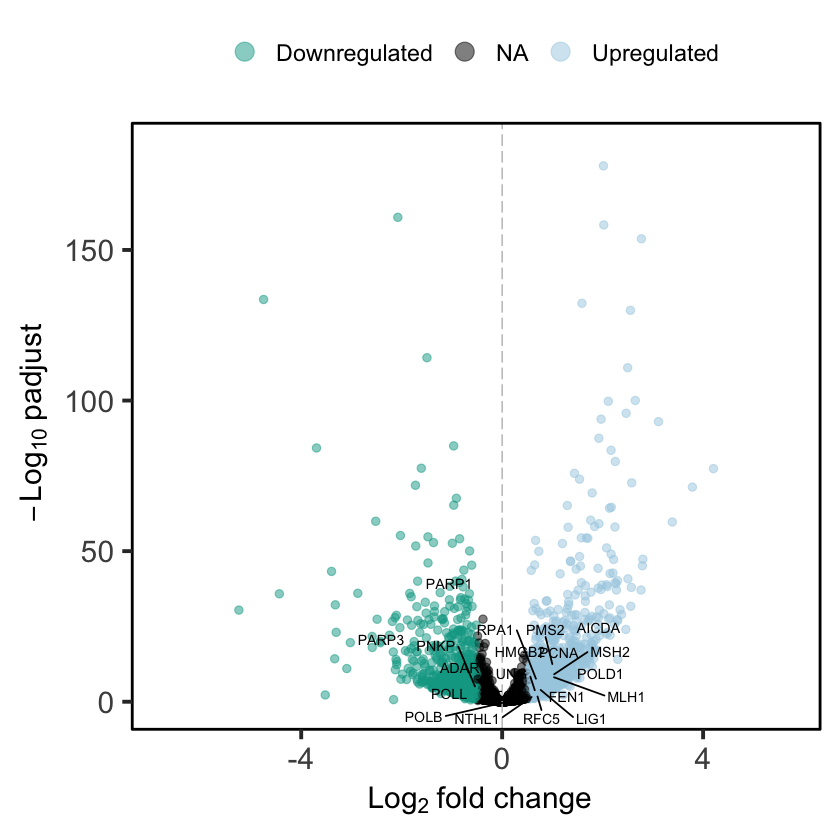

In [69]:
# create custom key-value pairs for high, low, mid expression
keyvals <- rep("black", nrow(DE_scSHM))
names(keyvals) <- rep("NA", nrow(DE_scSHM))

keyvals[which(DE_scSHM$log2FoldChange > 0.5)] <- "#a6cee3"
names(keyvals)[which(DE_scSHM$log2FoldChange > 0.5)] <- "Upregulated"

keyvals[which(DE_scSHM$log2FoldChange < -0.5)] <- "#00A693"
names(keyvals)[which(DE_scSHM$log2FoldChange < -0.5)] <- "Downregulated"

ev <- EnhancedVolcano(DE_scSHM,lab = DE_scSHM$rowname, x = "log2FoldChange",y = "padj",
                       pCutoff = F,
                       FCcutoff = F,
                            border = "full",
#        selectLab = filtered_genes,    #DE_scSHM$rowname[which(names(keyvals) %in% c("Upregulated", "Downregulated"))],
        borderWidth = 0.8,borderColour = "black",
        labSize = 5,
#        boxedLabels = TRUE,
        gridlines.major = FALSE,

        gridlines.minor = FALSE,
#        boxedLabels = TRUE,
 #       cutoffLineType = NULL,
        cutoffLineCol = "grey",
        col = c("#a6cee3","#1f78b4" ,"#b2df8a" ,"#33a02c"),
        title= NULL,
        subtitle=NULL,
        colCustom = keyvals,
        caption = NULL,
        ylab = bquote(~-Log[10] ~ padjust)) +
geom_text_repel(
  data = DE_scSHM %>% filter(rowname %in% filtered_genes),
  aes(x = log2FoldChange, y = -log10(padj), label = rowname),
  size = 3,
  max.overlaps = Inf
)


ev

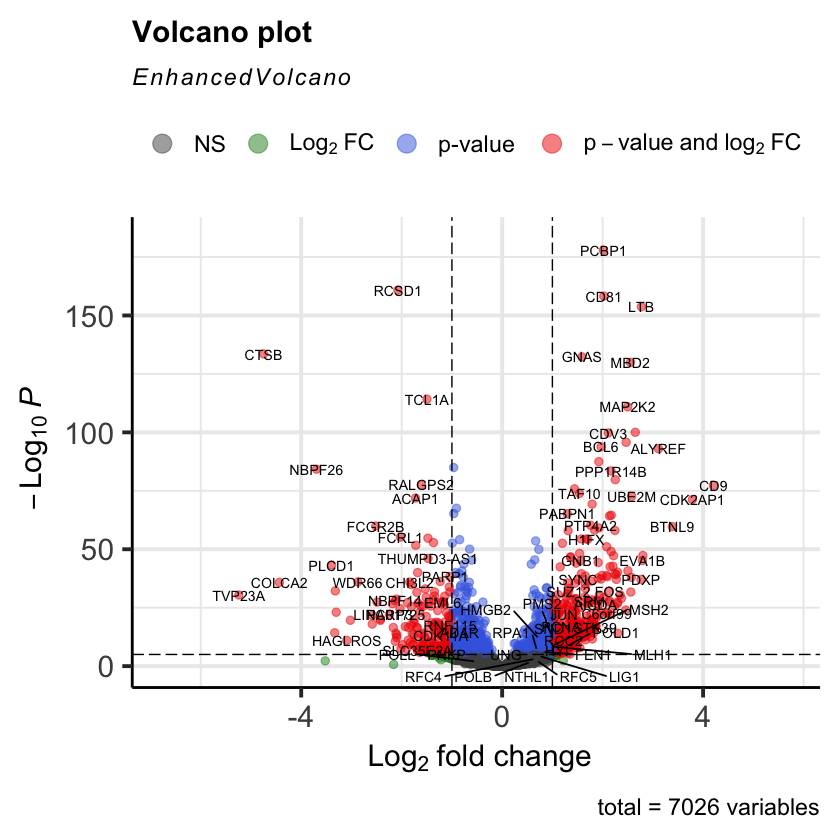

In [64]:

ev <- EnhancedVolcano(
  DE_scSHM,
  lab = DE_scSHM$rowname,
  x = "log2FoldChange",
  y = "padj",
#  selectLab = filtered_genes,
  labSize = 3
) +
geom_text_repel(
  data = DE_scSHM %>% filter(rowname %in% filtered_genes),
  aes(x = log2FoldChange, y = -log10(padj), label = rowname),
  size = 3,
  max.overlaps = Inf
)

ev

In [33]:
fig_save(ev , filename = ("figs_paper/test_volcano_plot"), formats = c("pdf", "png"), width = 20, height =12, units = "cm", dpi = 320)

In [29]:
#fig_save(ev , filename = ("figs_paper/volcano_plot"), formats = c("pdf", "png"), width = 20, height =12, units = "cm", dpi = 320)

## Another plotting for DE

In [7]:
results(dds)

log2 fold change (MLE): condition2 
LRT p-value: '~ batch + condition' vs '~ 1' 
DataFrame with 7026 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat       pvalue
          <numeric>      <numeric> <logical> <numeric>    <numeric>
NOC2L     0.2270913     -0.0733157        NA   9.50315  4.11524e-13
ISG15     0.0829845     -0.0886571        NA  13.35317  3.11665e-19
SDF4      0.2956741      0.7077189        NA  12.68068  3.70697e-18
UBE2J2    0.2598884      0.0431379        NA  10.69573  5.36221e-15
INTS11    0.2711895     -0.0370490        NA   6.14246  6.68334e-08
...             ...            ...       ...       ...          ...
TUG1      0.0916119       0.177524        NA   7.70805  2.64154e-10
MRTFA     0.1776842       0.637385        NA  13.43613  2.29563e-19
LINC01278 0.0578575       0.762119        NA  11.99861  4.54510e-17
SEPTIN6   1.0435942      -0.306244        NA  75.04192 5.18189e-116
PRKY      0.0637506      -1.542756        NA  11.11566  1.15559e

In [9]:
# Set thresholds
padj_cutoff <- 0.05

# Subset the significant results
sig_res <- filter(DE_scSHM, padj < padj_cutoff) %>%
        dplyr::arrange(padj)

# Check significant genes output
head(sig_res)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
DNER,0.1386676,-0.22631975,NA,418.0380,0,0
MTRNR2L12,1.2900551,0.20980774,NA,1489.5356,0,0
DUSP1,0.5069365,0.39375703,NA,256.3425,0,0
GMDS,0.3586152,-0.62927631,NA,303.4613,0,0
HLA-C,11.7543740,0.04704688,NA,259.5537,0,0
HLA-DQB1,4.0674597,0.07804472,NA,335.8776,0,0


In [15]:
ei <- d %>% rownames_to_column(var="samplename") %>% mutate(samplename = str_replace(samplename,"-",".")) 

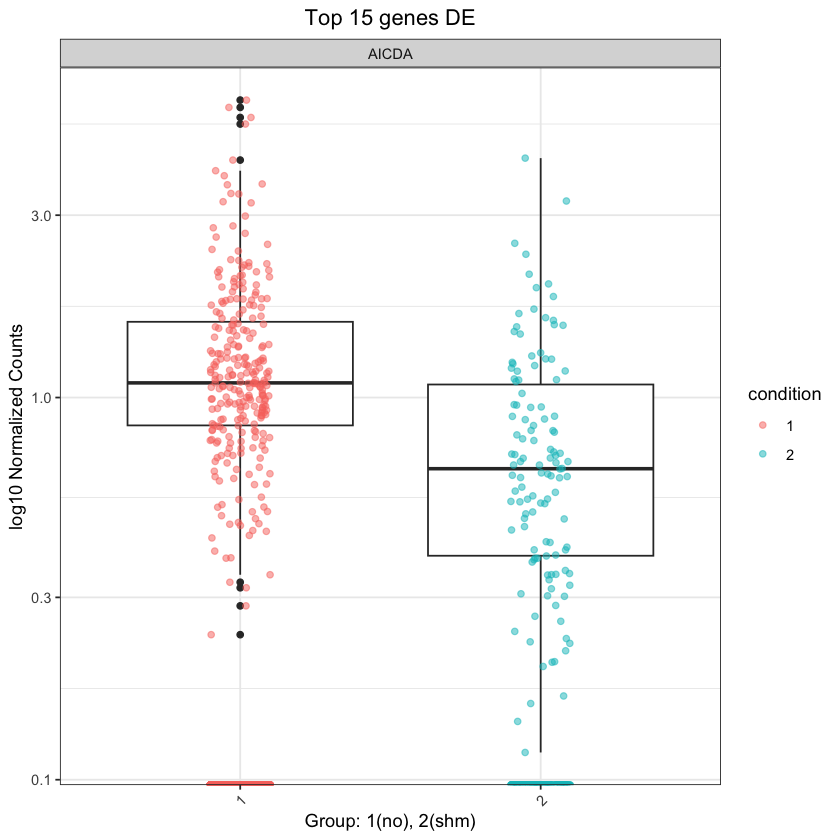

In [28]:
## ggplot of top genes
normalized_counts <- counts(dds, 
                            normalized = TRUE)

# Order results by padj values
top20_sig_genes <- sig_res %>%
        dplyr::arrange(padj) %>%
        dplyr::pull(rowname) %>%
        head(n=15)

#top20_sig_genes <- c("JUND",'LAPTM5','CD74','IL32','RNF213','TSC22D3','PEBP1','FTL','CD79A','IRF1','HLA-DRB1')

top20_sig_genes <- c("AICDA")


top20_sig_norm <- data.frame(normalized_counts) %>%
        rownames_to_column(var = "gene") %>%
        dplyr::filter(gene %in% top20_sig_genes)

gathered_top20_sig <- top20_sig_norm %>%
        gather(colnames(top20_sig_norm)[2:length(colnames(top20_sig_norm))], key = "samplename", value = "normalized_counts")
        
gathered_top20_sig <- inner_join(ei[, c("samplename", "condition" )], gathered_top20_sig, by = c("samplename"))

## plot using ggplot2
sii <- ggplot(gathered_top20_sig) +
     geom_boxplot(aes(x=condition, y=normalized_counts)) +
        geom_point(aes(x = condition, 
                       y = normalized_counts, 
                       color = condition), 
                   position=position_jitter(w=0.1,h=0), alpha=.5) +
        scale_y_log10() +
        xlab("Group: 1(no), 2(shm)") +
        ylab("log10 Normalized Counts") +
        ggtitle("Top 15 genes DE") +
        theme_bw() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
        theme(plot.title = element_text(hjust = 0.5)) +
facet_grid(.~gene)

sii

In [29]:
top20_sig_genes

[1] "AICDA"

In [30]:
fig_save(sii , filename = ("figs_paper/top15_DEgenes"), formats = c("pdf", "png"), width = 25, height =15, units = "cm", dpi = 320)

In [31]:
ei <- ei %>% mutate(samplename = str_replace(samplename,"-","."))

In [36]:
head(gathered_top20_sig,30)

,samplename,condition,gene,normalized_counts
,<chr>,<fct>,<chr>,<dbl>
1,AGCTTGACAATGGACG.1_1,2,AICDA,0.0000000
2,CTAGCCTCAATCACAC.1_1,2,AICDA,0.0000000
3,CGAGCACAGGTTCCTA.1_1,2,AICDA,0.6522107
4,ATCATGGGTGGTCTCG.1_1,2,AICDA,0.0000000
5,TCTTTCCGTCTAGTCA.1_1,2,AICDA,0.0000000
6,ACGCCAGAGGCATTGG.1_1,2,AICDA,0.0000000
7,CACATAGTCATACGGT.1_1,2,AICDA,0.6174727
8,TGTGGTAAGGCGACAT.1_1,2,AICDA,0.0000000
9,CAAGTTGCAGCTGTGC.1_1,2,AICDA,0.0000000


#### check expression CTSB in differents chips

In [35]:
gathered_top20_sig %>% mutate(chip =str_extract(samplename, ".{1}$")) %>% #filter(gene == "CTSB", subject == "4")
group_by(condition,gene) %>% summarize(mean_by_gene = mean(normalized_counts)) #%>% filter(gene %like% "CTSB")

`summarise()` has grouped output by 'condition'. You can override using the `.groups` argument.


condition,gene,mean_by_gene
<fct>,<chr>,<dbl>
1,AICDA,0.09803076
2,AICDA,0.27299591


In [120]:
gathered_top20_sig %>% mutate(chip =str_extract(samplename, ".{1}$")) %>% filter(chip == "2") %>% pull(samplename) %>%
                                                                                                           unique() #filter(samplename %like% "GAGCAGACAGGGATTG") #filter(group == "2",gene == "CTSB")

[1] "GAGGTGACAGTATGCT.1_2" "TACCTATAGCGATCCC.1_2" "CAGTAACCATATGGTC.1_2"
 [4] "GGAAAGCCAAGTCTGT.1_2" "ATTGGACCACACCGCA.1_2" "TGAGCATGTTCCATGA.1_2"
 [7] "CGCGGTATCAGGCAAG.1_2" "TAAGAGATCAAACCGT.1_2" "GATCGTATCCCATTTA.1_2"
[10] "AACTCCCAGCGATATA.1_2" "CGAGAAGCAGGAACGT.1_2" "TGAGAGGAGTGAAGTT.1_2"
[13] "AAACCTGTCTTTAGTC.1_2" "AAAGTAGGTCCTCTTG.1_2" "AAGGTTCAGGAACTGC.1_2"
[16] "AGAGTGGGTACTTCTT.1_2" "CAACTAGAGGGTCGAT.1_2" "CAACTAGTCAAAGACA.1_2"
[19] "CAGAATCGTTCAACCA.1_2" "CCACCTATCAACGGGA.1_2" "CCTTCCCAGTGTGAAT.1_2"
[22] "CGAACATCAAGACGTG.1_2" "CGATTGACAGGCAGTA.1_2" "CGGACACTCTCTTATG.1_2"
[25] "CTAATGGAGTCGCCGT.1_2" "CTACCCAGTGGCGAAT.1_2" "CTCAGAAGTGTAAGTA.1_2"
[28] "CTCTGGTCACACGCTG.1_2" "GACGTTACACGTAAGG.1_2" "GAGCAGACAATAGAGT.1_2"
[31] "GATGAGGGTTCGGGCT.1_2" "GCATGCGGTCGACTAT.1_2" "GCGCAGTAGCTAAGAT.1_2"
[34] "GCTGCTTGTGGGTATG.1_2" "TAAACCGAGACTTTCG.1_2" "TAAACCGGTACAGCAG.1_2"
[37] "TACGGGCAGCACACAG.1_2" "TACTTACAGTCTCCTC.1_2" "TATCTCACAACTGGCC.1_2"
[40] "TCAGATGTCAAACCAC.1_2" "TCAGCAAAGAGCTGGT.1_2" "TCAGGATAGTGGACGT.1_2"
[43] "TGAGCCGTCTCGTATT.1_2" "TGCGTGGGTGCATCTA.1_2" "TGCGTGGTCAACCATG.1_2"
[46] "TGGACGCGTAGGGACT.1_2" "CGGAGTCCACTCGACG.1_2" "CAAGATCTCAATCACG.1_2"
[49] "TGTGTTTAGACTGGGT.1_2" "CACCACTAGCCTCGTG.1_2" "GGCTGGTTCCCACTTG.1_2"
[52] "AAACGGGCACGGTAGA.1_2" "AGCTCCTCATGCAACT.1_2" "TCCCGATCAATGGAAT.1_2"
[55] "CTAATGGTCATTGCCC.1_2"

In [8]:
gathered_top20_sig %>% filter(condition == "2",gene == "AICDA")

ERROR: Error in filter(., condition == "2", gene == "AICDA"): object 'gathered_top20_sig' not found


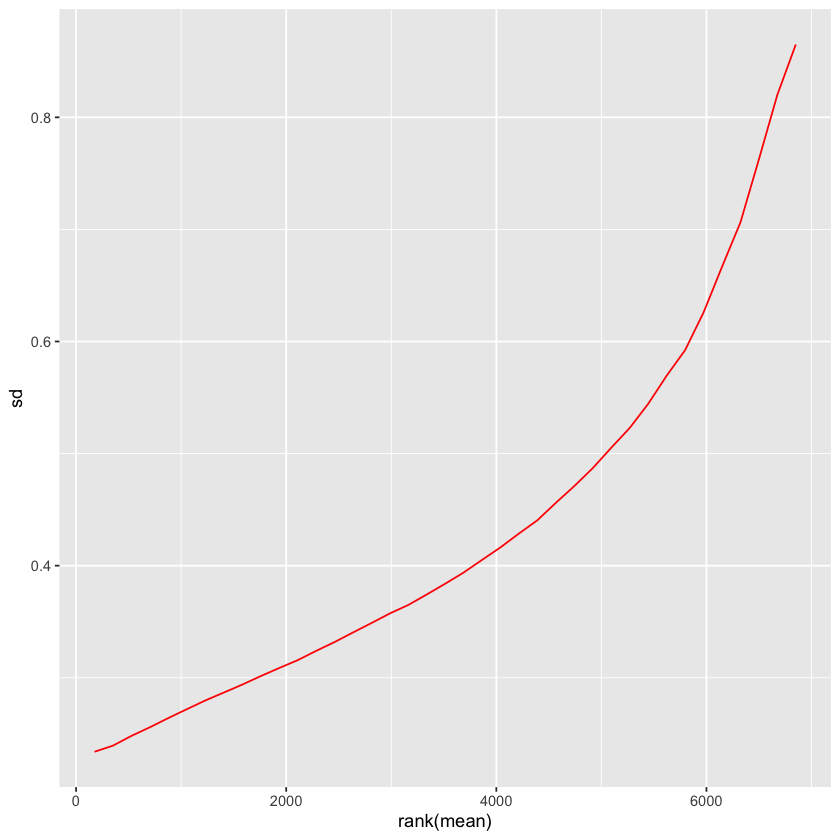

In [122]:
# this gives log2(n + 1)
ntd <- normTransform(dds)
library("vsn")
meanSdPlot(assay(ntd))

In [123]:
colData(dds)

DataFrame with 4052 rows and 4 columns
                        batch condition  cluster sizeFactor
                     <factor>  <factor> <factor>  <numeric>
AGCTTGACAATGGACG-1_1      K1B         2        2   1.155350
CTAGCCTCAATCACAC-1_1      K1B         2        2   0.777052
CGAGCACAGGTTCCTA-1_1      K1B         2        2   3.066494
ATCATGGGTGGTCTCG-1_1      K1B         2        2   1.251420
TCTTTCCGTCTAGTCA-1_1      K1B         2        2   1.362156
...                       ...       ...      ...        ...
ACATACGGTCCAGTTA-1_8      K8B         1        1   1.131128
GCAGCCACATCACGTA-1_8      K8B         1        1   1.051387
GAACCTATCAGATAAG-1_8      K8B         1        1   0.867889
AGTTGGTGTGCAGTAG-1_8      K8B         1        1   2.241964
ACTTGTTGTCTTTCAT-1_8      K8B         1        1   1.136211

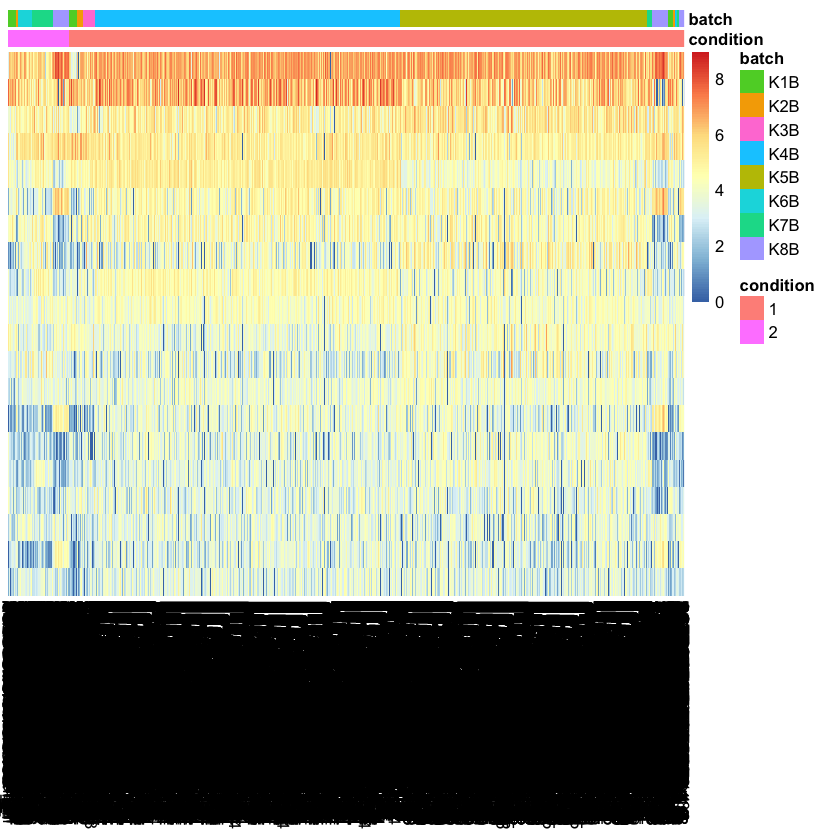

In [124]:
library("pheatmap")
select <- order(rowMeans(counts(dds,normalized=TRUE)),
                decreasing=TRUE)[1:20]
df <- as.data.frame(colData(dds)[,c("condition","batch")])
pheatmap(assay(ntd)[select,], cluster_rows=FALSE, show_rownames=FALSE,
         cluster_cols=FALSE, annotation_col=df)

In [ ]:
vsd <- vst(dds, blind=FALSE, nsub=48)
rld <- rlog(dds, blind=FALSE)
head(assay(vsd), 3)

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

rlog() may take a long time with 50 or more samples,
vst() is a much faster transformation



In [ ]:
sum( rowMeans( counts(dds, normalized=TRUE)) > 5 )

In [126]:
nrow(dds)

[1] 6604